# Notebook 1: Exploratory Data Analysis
## US Census Income Dataset -- Who Earns Over $50K?

**Goal:** Build a thorough understanding of the data before modeling -- distributions, quality issues, relationships, and the story the data tells about income in America.

**Key design decisions documented here:**
- How missing values are handled
- Why instance weights matter for valid conclusions
- Which features carry the most signal
- Class imbalance implications for modeling

In [1]:
%matplotlib inline

import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from src.utils import (
    COLUMN_NAMES, CONTINUOUS_COLS, MIGRATION_COLS,
    TARGET_COL, INSTANCE_WEIGHT_COL, EDUCATION_ORDER,
    INCOME_PALETTE, INCOME_LABELS, TARGET_MAP,
    TRAIN_PATH, TEST_PATH, FIGURES_DIR, DOCS_DIR,
    FIGURE_DPI, RANDOM_STATE
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': FIGURE_DPI, 'figure.figsize': (12, 5)})
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str):
    path = FIGURES_DIR / f'{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=FIGURE_DPI)
    plt.show()

## 1. Data Loading

The raw CSV files have no header row. Column names are assigned from the metadata file. Key preprocessing on load:
- Strip whitespace from all string values (raw data has leading spaces)
- Replace `'?'` with `NaN` (missing value encoding used in this dataset)
- Map the target variable to binary integers: 0 = `< $50K`, 1 = `>= $50K`

In [2]:
def load_census(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        header=None,
        names=COLUMN_NAMES,
        na_values=['?', ' ?'],
        skipinitialspace=True,
    )
    # Standardize string columns: strip whitespace and trailing periods
    str_cols = df.select_dtypes(include=['object']).columns
    df[str_cols] = df[str_cols].apply(lambda s: s.str.strip().str.rstrip('.'))
    # Binary target
    df[TARGET_COL] = df[TARGET_COL].map(TARGET_MAP)
    return df

train = load_census(TRAIN_PATH)
test  = load_census(TEST_PATH)

print(f'Train: {train.shape}  |  Test: {test.shape}')
print(f'\nColumn dtypes:\n{train.dtypes.value_counts()}')
train.head(3)

Train: (199523, 42)  |  Test: (99762, 42)

Column dtypes:
str        28
int64      13
float64     1
Name: count, dtype: int64


,age,class_of_worker,detailed_industry_recode,detailed_occupation_recode,education,wage_per_hour,enroll_edu_inst,marital_status,major_industry_code,major_occupation_code,...,birth_country_father,birth_country_mother,birth_country_self,citizenship,own_business_self_employed,veteran_admin_questionnaire,veterans_benefits,weeks_worked_year,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,0
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,0


## 2. Data Quality Audit

In [3]:
# --- Missing values ---
missing = (
    train.isnull().sum()
    .rename('count')
    .to_frame()
    .assign(pct=lambda d: 100 * d['count'] / len(train))
    .query('count > 0')
    .sort_values('pct', ascending=False)
)
print('Features with missing values (train):')
display(missing)

Features with missing values (train):


,count,pct
migration_msa,99696,49.967172
migration_reg,99696,49.967172
migration_within_reg,99696,49.967172
migration_sunbelt,99696,49.967172
birth_country_father,6713,3.364524
birth_country_mother,6119,3.066814
birth_country_self,3393,1.700556
hispanic_origin,874,0.438045
state_prev_residence,708,0.354846


**Reading the output above:**

Three distinct missingness patterns, each with a different explanation:

1. **Migration columns (~50% missing, all four missing on identical records):** `migration_msa`, `migration_reg`, `migration_within_reg`, and `migration_sunbelt` are all missing for the same 99,696 records. This is **structural missingness** -- non-movers have no "previous residence" to report. It is not random data quality noise; the missingness itself is informative. We preserve it as a dedicated `"Non-mover"` category rather than imputing.

2. **Parental birth country (~3-3.4% missing):** `birth_country_father` and `birth_country_mother`. Likely US-born respondents for whom this field was not collected. Treated as a `"Missing"` category.

3. **Everything else: 0% missing.** The dataset is otherwise complete -- a property of being a carefully designed government survey.

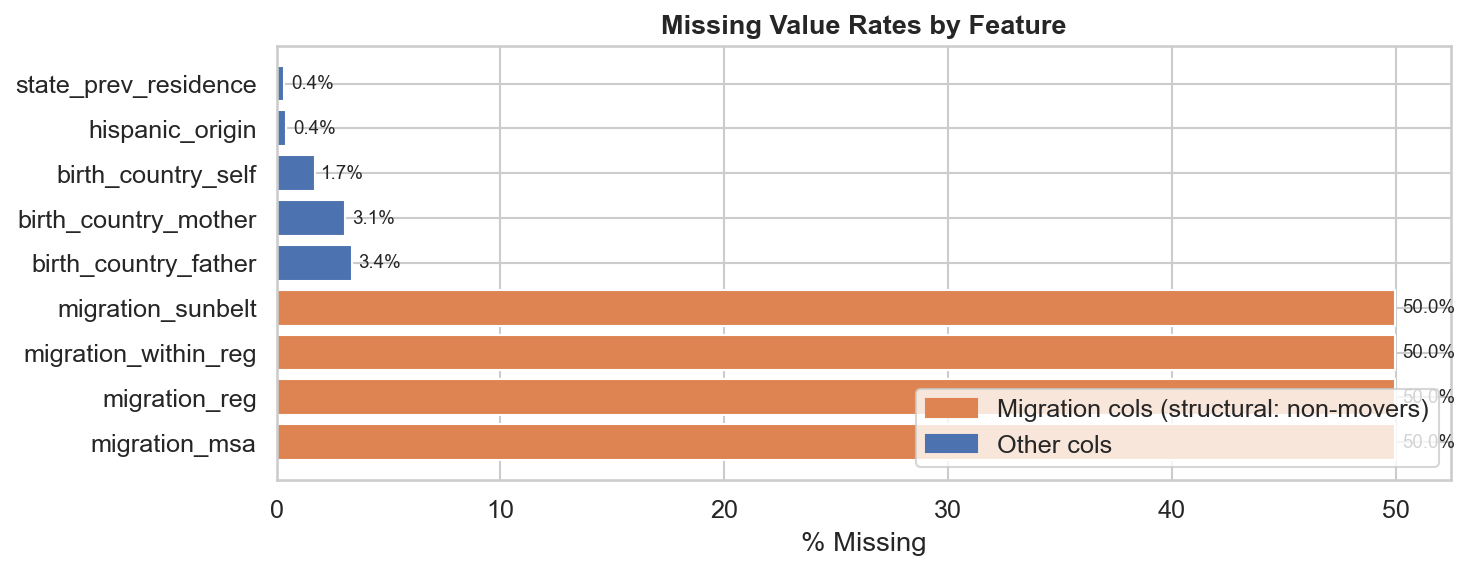

In [4]:
fig, ax = plt.subplots(figsize=(10, max(4, len(missing) * 0.35)))
bars = ax.barh(
    missing.index, missing['pct'],
    color=['#DD8452' if c in MIGRATION_COLS else '#4C72B0' for c in missing.index]
)
ax.set_xlabel('% Missing')
ax.set_title('Missing Value Rates by Feature', fontsize=13, fontweight='bold')
# Annotate bars
for bar, (_, row) in zip(bars, missing.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{row['pct']:.1f}%", va='center', fontsize=9)
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#DD8452', label='Migration cols (structural: non-movers)'),
    Patch(color='#4C72B0', label='Other cols')
], loc='lower right')
plt.tight_layout()
savefig('01_missing_values')

In [5]:
# --- Duplicates ---
# The metadata notes 46,716 duplicate/conflicting instances in train
feature_cols = [c for c in train.columns if c not in [TARGET_COL, INSTANCE_WEIGHT_COL]]
n_exact_dupes = train.duplicated(subset=feature_cols + [TARGET_COL]).sum()
n_conflicting = train.duplicated(subset=feature_cols).sum() - n_exact_dupes

print(f'Exact duplicates (same features + label): {n_exact_dupes:,}')
print(f'Conflicting instances (same features, different label): {n_conflicting:,}')
print()
print('Decision: Retain all records. The instance_weight column accounts for')
print('stratified sampling -- deduplication would distort population estimates.')

Exact duplicates (same features + label): 46,627
Conflicting instances (same features, different label): 89

Decision: Retain all records. The instance_weight column accounts for
stratified sampling -- deduplication would distort population estimates.


**Why we keep all records despite 46K duplicates:**

The dataset is a stratified random sample from the full US population. Duplicate feature combinations are expected -- many Americans share the same demographic profile (e.g., 35-year-old high school graduate, full-time private sector, single). Removing duplicates would bias the sample away from its population design and distort any weighted statistic. The 89 conflicting instances (same features, different income label) are acceptable label noise in a large survey.

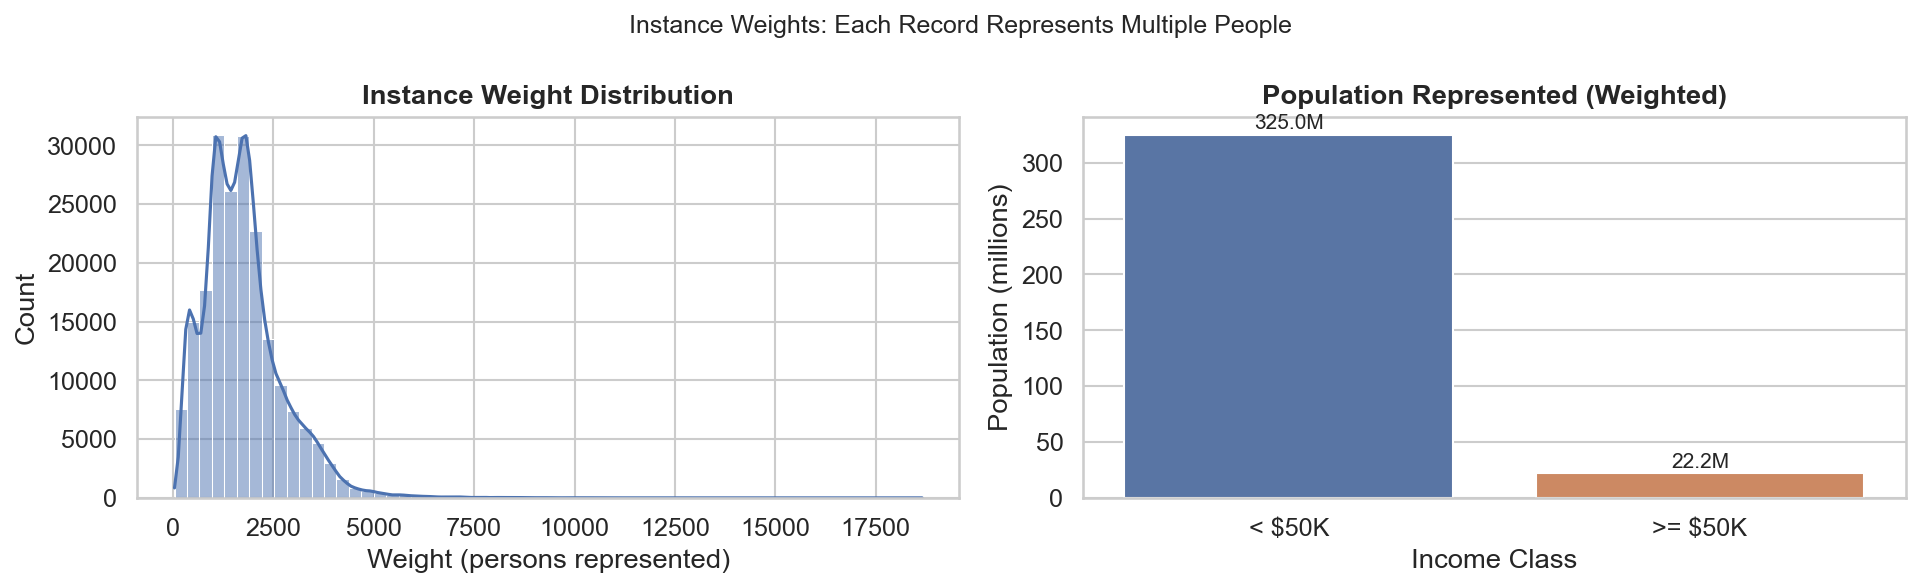

In [6]:
# --- Instance weight distribution ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(train[INSTANCE_WEIGHT_COL], bins=60, kde=True, ax=ax1, color='#4C72B0')
ax1.set_title('Instance Weight Distribution', fontweight='bold')
ax1.set_xlabel('Weight (persons represented)')

# Weight by income class
wt_by_class = train.groupby(TARGET_COL)[INSTANCE_WEIGHT_COL].sum().reset_index()
wt_by_class['label'] = wt_by_class[TARGET_COL].map(INCOME_LABELS)
wt_by_class['millions'] = wt_by_class[INSTANCE_WEIGHT_COL] / 1e6
sns.barplot(data=wt_by_class, x='label', y='millions', palette=INCOME_PALETTE,
            hue='label', ax=ax2, legend=False)
ax2.set_title('Population Represented (Weighted)', fontweight='bold')
ax2.set_ylabel('Population (millions)')
ax2.set_xlabel('Income Class')
for bar in ax2.patches:
    h = bar.get_height()
    if h > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, h + 5,
                 f'{h:.1f}M', ha='center', fontsize=10)

plt.suptitle('Instance Weights: Each Record Represents Multiple People', fontsize=12)
plt.tight_layout()
savefig('02_instance_weights')

**Why instance weights matter:**

The right panel shows why we use weighted statistics throughout this notebook. Without weights, the raw 6.2% positive class rate would imply ~12,000 high earners in the sample. But the weighted count (~22M) is the actual population estimate. Any percentage quoted as a "finding" (e.g., "33% of people with capital gains earn over $50K") is computed using these weights so it represents the real American population, not just the sample.

## 3. Target Variable: The Imbalance Problem

**Why this matters for modeling:** With 93.8% of records in the `< $50K` class, a naive model that predicts *always negative* achieves ~94% accuracy. Accuracy is therefore a misleading metric. We will use ROC-AUC and Precision-Recall AUC as primary evaluation metrics and apply class imbalance correction during training.

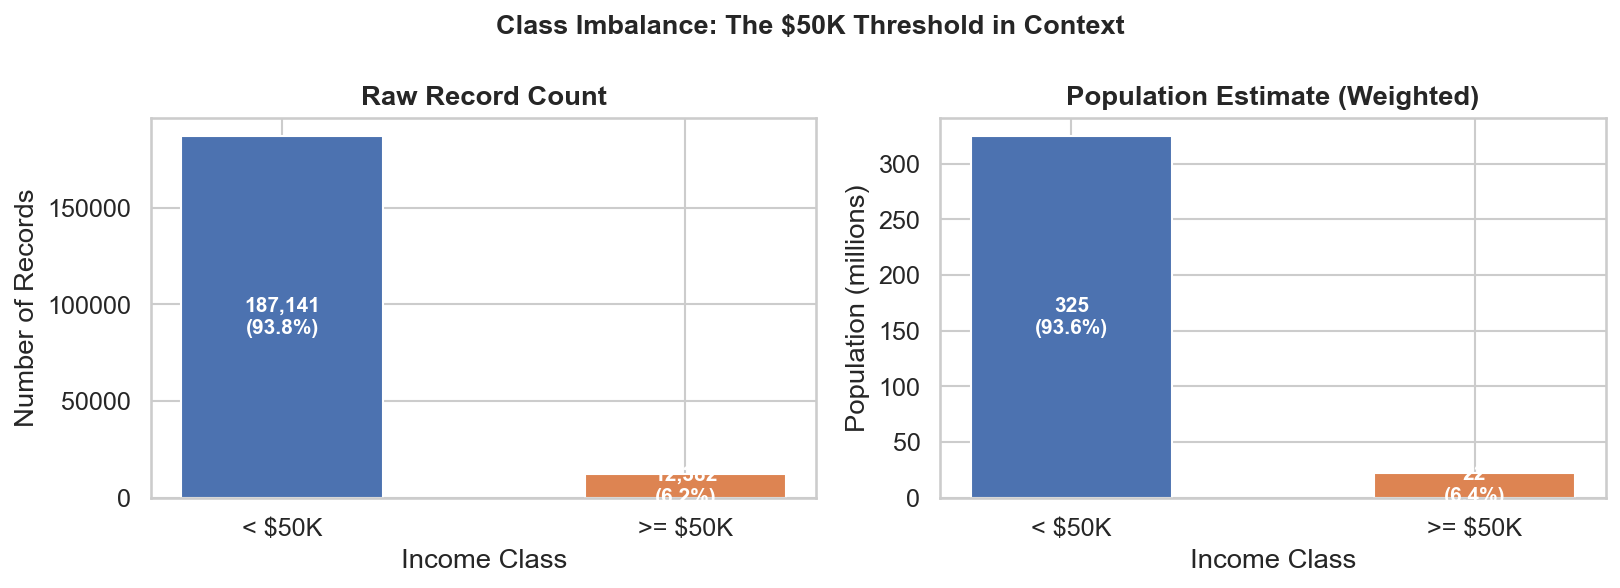

In [7]:
# Raw counts vs weighted population proportions
raw_counts = train[TARGET_COL].value_counts().sort_index()
weighted_counts = train.groupby(TARGET_COL)[INSTANCE_WEIGHT_COL].sum().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, counts, title, ylabel in [
    (axes[0], raw_counts, 'Raw Record Count', 'Number of Records'),
    (axes[1], weighted_counts / 1e6, 'Population Estimate (Weighted)', 'Population (millions)'),
]:
    labels = [INCOME_LABELS[i] for i in counts.index]
    colors = [INCOME_PALETTE[INCOME_LABELS[i]] for i in counts.index]
    bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Income Class')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        pct = 100 * val / total
        label = f'{val:,.0f}\n({pct:.1f}%)'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
                label, ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.suptitle('Class Imbalance: The $50K Threshold in Context', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('03_target_distribution')

**Class imbalance: what it means for modeling**

The 6.2%/93.8% split has direct consequences for every modeling decision downstream:

- **Accuracy is useless:** A model that always predicts "< $50K" scores 93.8% -- and identifies no high earners at all.
- **Primary metrics:** ROC-AUC (ranking quality) and PR-AUC (precision-recall balance on the minority class). Not accuracy, not F1 at the default 0.5 threshold.
- **Class weighting:** The LightGBM model uses `scale_pos_weight = 93.8 / 6.2 ≈ 15.2` to compensate. Without this, the model would heavily favour the majority class during training.
- **Threshold selection:** The optimal decision threshold will not be 0.5. On an imbalanced dataset, a calibrated model outputs low probabilities for most positives. The actual threshold that maximizes F1 turns out to be ~0.857 (determined in the modeling notebook).

## 4. Continuous Feature Distributions

We examine the 7 continuous features to understand their distributions, zero-inflation, and separability between income classes.

In [8]:
# Summary stats split by income class
def weighted_summary(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """Weighted mean and median by income class."""
    rows = []
    for inc, grp in df.groupby(TARGET_COL):
        w = grp[INSTANCE_WEIGHT_COL]
        v = grp[col]
        mask = v.notna()
        wm = np.average(v[mask], weights=w[mask])
        rows.append({'income': INCOME_LABELS[inc], 'weighted_mean': wm,
                     'raw_median': v.median(), 'zero_pct': 100*(v==0).mean()})
    return pd.DataFrame(rows)

for col in CONTINUOUS_COLS:
    print(weighted_summary(train, col).to_string(index=False))
    print()

 income  weighted_mean  raw_median  zero_pct
 < $50K      33.676008        31.0  1.517038
>= $50K      46.129831        45.0  0.000000

 income  weighted_mean  raw_median  zero_pct
 < $50K      55.723077         0.0 94.256737
>= $50K      81.373316         0.0 95.509611

 income  weighted_mean  raw_median  zero_pct
 < $50K     144.574620         0.0 97.345852
>= $50K    4781.242068         0.0 80.520110

 income  weighted_mean  raw_median  zero_pct
 < $50K      27.872649         0.0 98.537466
>= $50K     194.792756         0.0 90.558876

 income  weighted_mean  raw_median  zero_pct
 < $50K     109.484703         0.0 91.541137
>= $50K    1483.940367         0.0 57.107091

 income  weighted_mean  raw_median  zero_pct
 < $50K       1.876119         0.0 50.970658
>= $50K       4.028065         4.0  4.813439

 income  weighted_mean  raw_median  zero_pct
 < $50K      21.900271         0.0 50.970658
>= $50K      48.163953        52.0  4.813439



**Reading the summary stats table:**

Each block is one continuous feature, showing weighted mean, raw median, and % of zeros split by income class.

Key patterns:
- **Age:** Clear separation (mean 34 vs 46). No zeros -- everyone has an age. Best-behaved continuous predictor.
- **wage_per_hour:** ~94% zeros for both income classes. High earners are disproportionately *salaried* (no hourly rate). This is why wage_per_hour ranks poorly as a standalone predictor -- it is not reported for most workers.
- **capital_gains:** Only 3% zero for `>= $50K` vs 97% zero for `< $50K`. Huge mean difference (4,781 vs 145). The engineering decision: use a binary `has_capital_income` flag rather than the raw amount.
- **dividends_from_stocks:** 57% zero for high earners vs 92% for low earners. Same story as capital gains.
- **weeks_worked_year:** Median of 52 weeks for high earners vs 0 for low earners. High earners are almost universally full-year workers.
- **num_persons_employer:** ~51% zeros for both classes (children + not-in-universe). Modest difference in means.

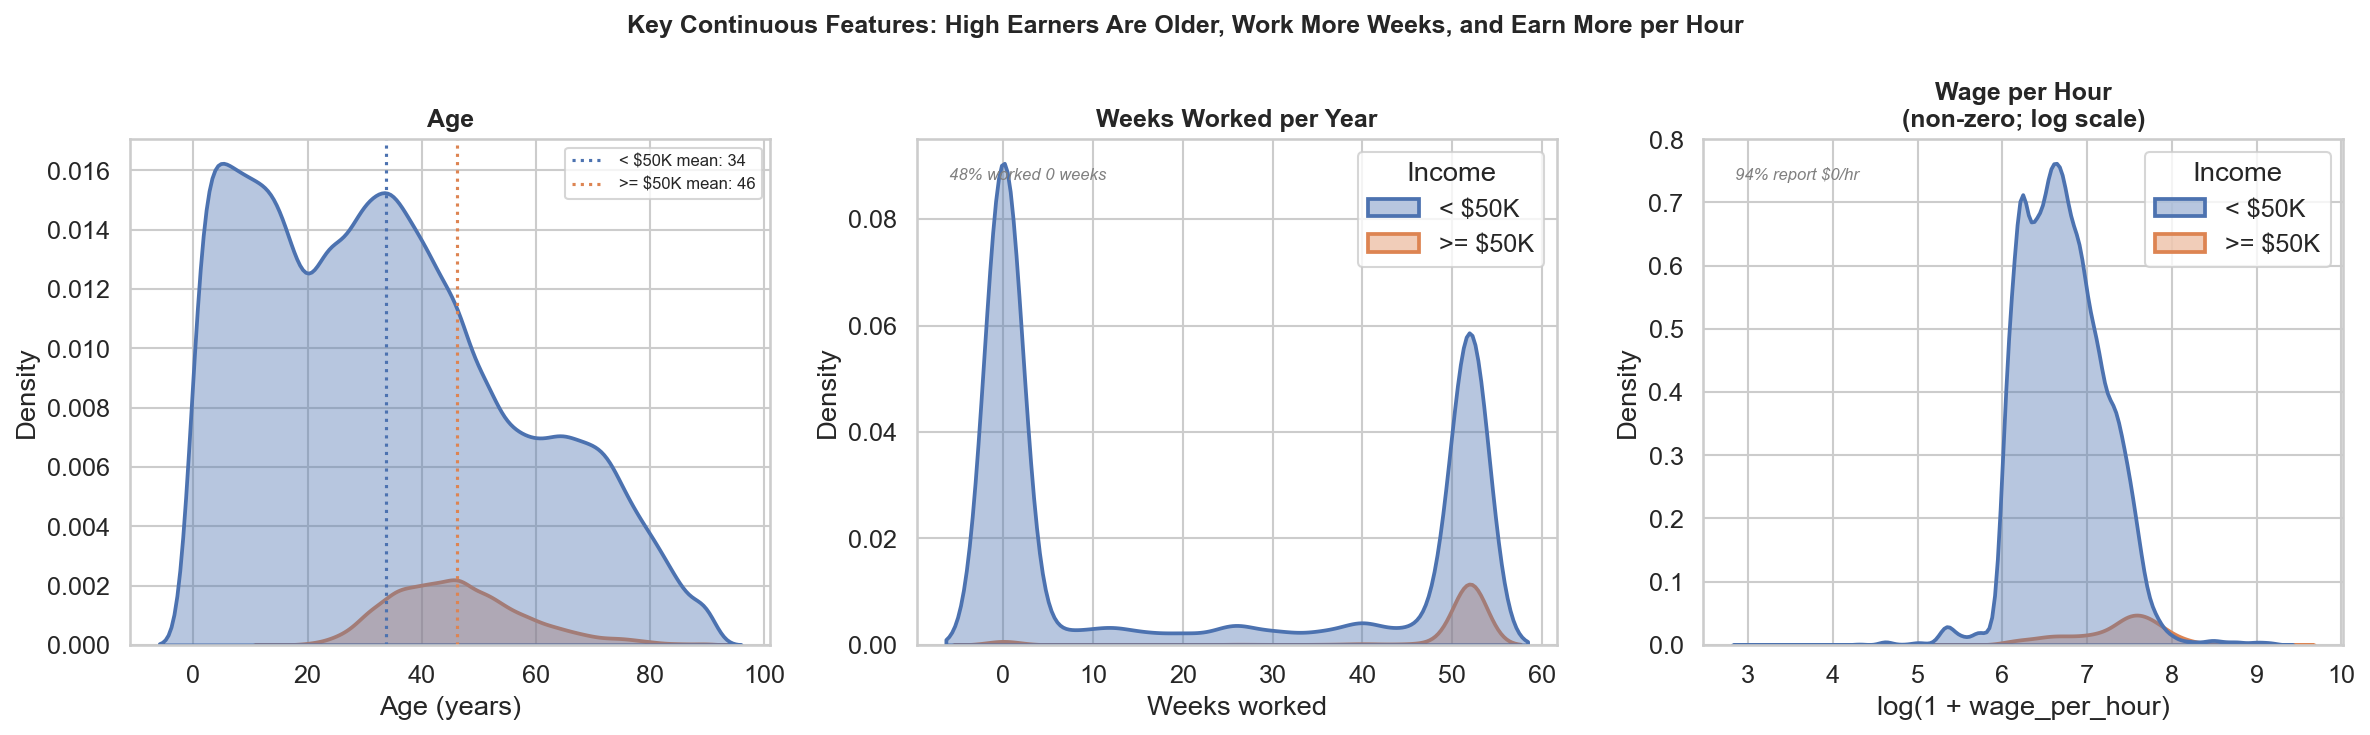

In [9]:
# Focused 3-panel chart: the three most story-worthy continuous features
# (capital income analysis gets its own dedicated chart below)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_data = train.copy()
plot_data['Income'] = plot_data[TARGET_COL].map(INCOME_LABELS)

# --- Age ---
sns.kdeplot(data=plot_data, x='age', hue='Income', ax=axes[0],
            palette=INCOME_PALETTE, fill=True, alpha=0.4, linewidth=1.8)
axes[0].set_title('Age', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Age (years)')
for inc_val, label in INCOME_LABELS.items():
    wmean = np.average(train['age'], weights=train[INSTANCE_WEIGHT_COL] * (train[TARGET_COL] == inc_val))
    axes[0].axvline(wmean, color=INCOME_PALETTE[label], linestyle=':', linewidth=1.5,
                    label=f'{label} mean: {wmean:.0f}')
axes[0].legend(fontsize=8)

# --- Weeks worked per year ---
sns.kdeplot(data=plot_data, x='weeks_worked_year', hue='Income', ax=axes[1],
            palette=INCOME_PALETTE, fill=True, alpha=0.4, linewidth=1.8)
axes[1].set_title('Weeks Worked per Year', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Weeks worked')
axes[1].text(0.05, 0.92, f'{(train["weeks_worked_year"]==0).mean()*100:.0f}% worked 0 weeks',
             transform=axes[1].transAxes, fontsize=8, color='gray', style='italic')

# --- Wage per hour (non-zero) ---
nz_wage = plot_data[plot_data['wage_per_hour'] > 0].copy()
nz_wage['wage_log'] = np.log1p(nz_wage['wage_per_hour'])
sns.kdeplot(data=nz_wage, x='wage_log', hue='Income', ax=axes[2],
            palette=INCOME_PALETTE, fill=True, alpha=0.4, linewidth=1.8)
axes[2].set_title('Wage per Hour\n(non-zero; log scale)', fontweight='bold', fontsize=12)
axes[2].set_xlabel('log(1 + wage_per_hour)')
axes[2].text(0.05, 0.92, f'{(train["wage_per_hour"]==0).mean()*100:.0f}% report $0/hr',
             transform=axes[2].transAxes, fontsize=8, color='gray', style='italic')

plt.suptitle('Key Continuous Features: High Earners Are Older, Work More Weeks, and Earn More per Hour',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('04_continuous_distributions')

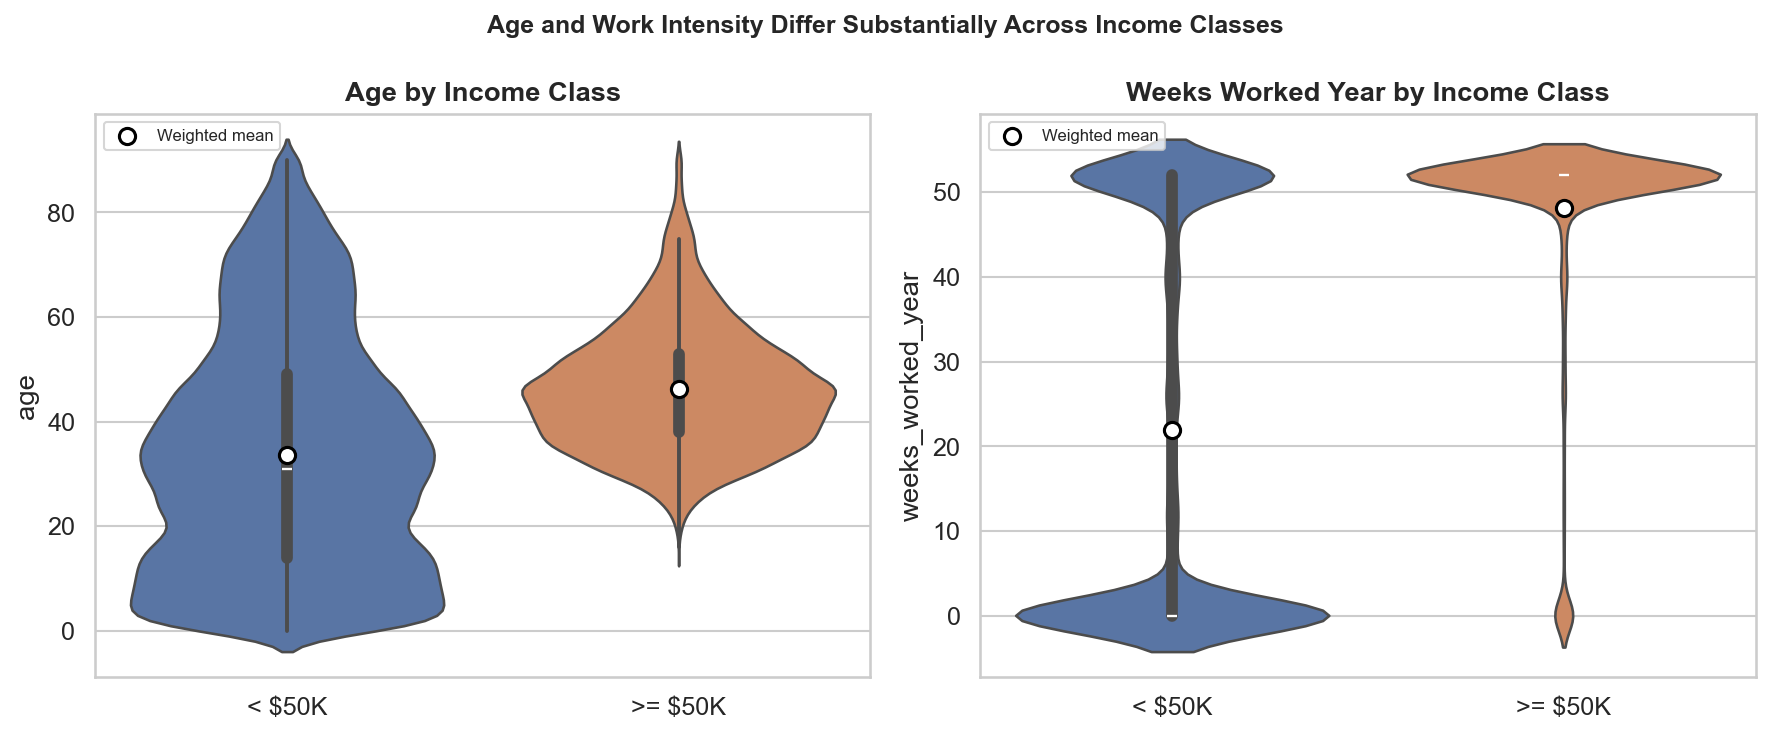

In [10]:
# Box plots: age and weeks worked (most interpretable continuous predictors)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_data = train.copy()
plot_data['Income'] = plot_data[TARGET_COL].map(INCOME_LABELS)

for ax, col in zip(axes, ['age', 'weeks_worked_year']):
    sns.violinplot(data=plot_data, x='Income', y=col, hue='Income',
                   palette=INCOME_PALETTE, ax=ax, legend=False, inner='box')
    # Add weighted means
    for j, (inc_val, grp) in enumerate(train.groupby(TARGET_COL)):
        w_mean = np.average(grp[col].dropna(), weights=grp.loc[grp[col].notna(), INSTANCE_WEIGHT_COL])
        ax.scatter(j, w_mean, color='white', s=60, zorder=5, edgecolors='black', linewidth=1.5,
                   label='Weighted mean' if j == 0 else '')
    ax.set_title(f'{col.replace("_", " ").title()} by Income Class', fontweight='bold')
    ax.set_xlabel('')
    ax.legend(loc='upper left', fontsize=8)

plt.suptitle('Age and Work Intensity Differ Substantially Across Income Classes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('05_age_weeks_violin')

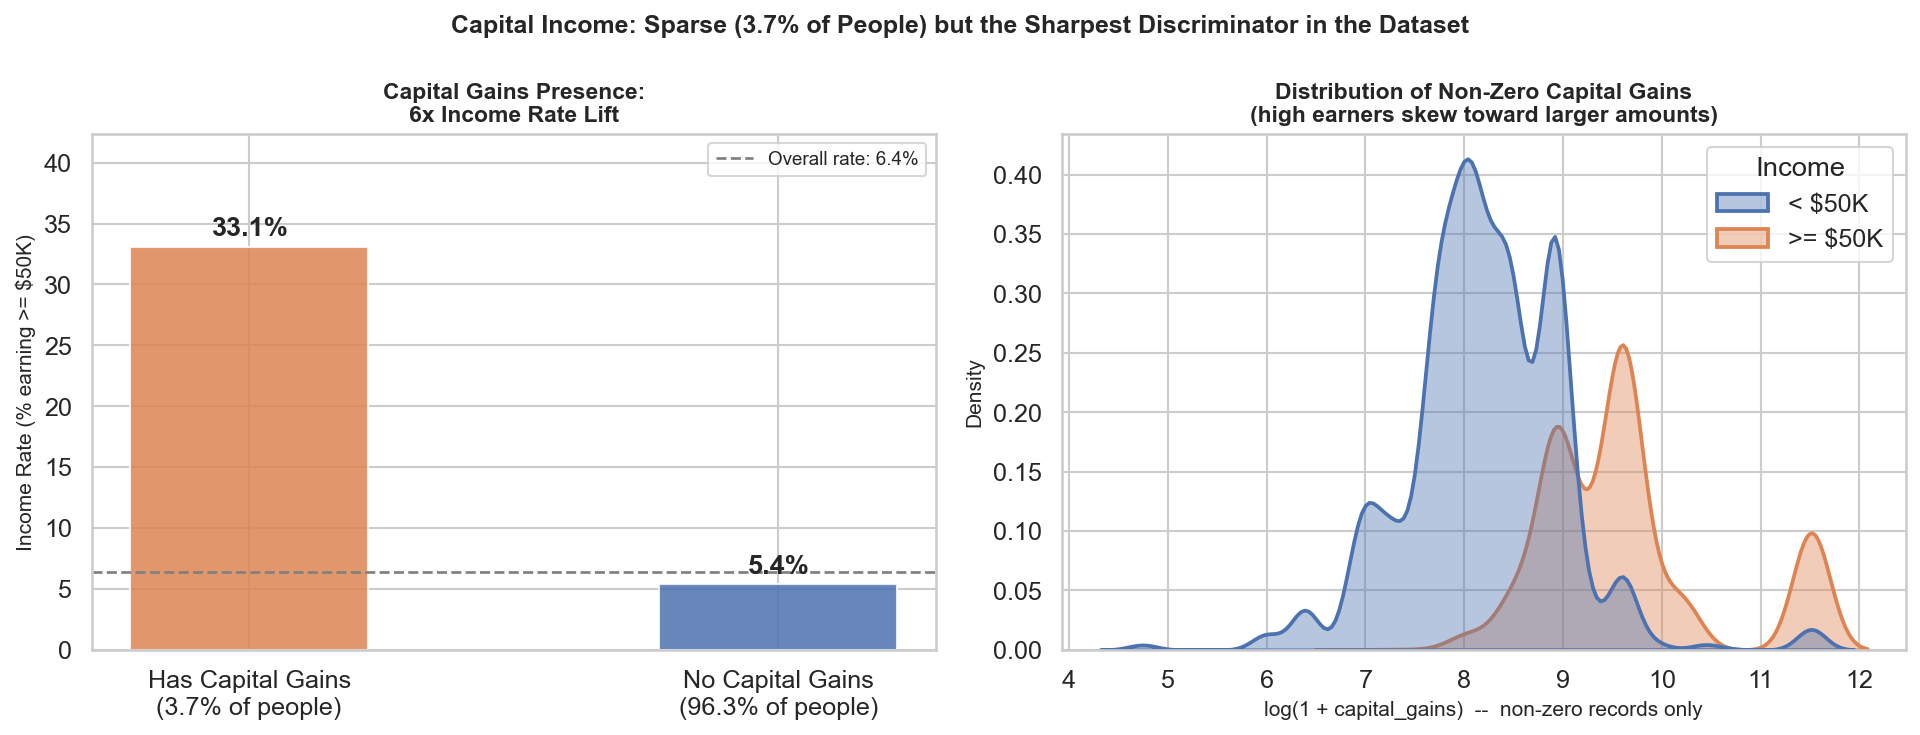

In [11]:
# Capital income: clean 2-panel analysis
# Panel 1: income rate by presence/absence (the 6x lift story)
# Panel 2: distribution of non-zero values by income class (no twinx)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_data = train.copy()
plot_data['Income'] = plot_data[TARGET_COL].map(INCOME_LABELS)

# --- Panel 1: income rate by capital gains presence ---
w = train[INSTANCE_WEIGHT_COL]
has_cap = train['capital_gains'] > 0
no_cap  = ~has_cap

rate_has     = (train.loc[has_cap, TARGET_COL] * w[has_cap]).sum() / w[has_cap].sum()
rate_no      = (train.loc[no_cap,  TARGET_COL] * w[no_cap] ).sum() / w[no_cap] .sum()
pct_has      = w[has_cap].sum() / w.sum() * 100
overall_rate = (train[TARGET_COL] * w).sum() / w.sum() * 100

bar_labels = [
    f'Has Capital Gains\n({pct_has:.1f}% of people)',
    f'No Capital Gains\n({100-pct_has:.1f}% of people)',
]
bars = axes[0].bar(
    bar_labels,
    [rate_has * 100, rate_no * 100],
    color=[INCOME_PALETTE[INCOME_LABELS[1]], INCOME_PALETTE[INCOME_LABELS[0]]],
    alpha=0.85, width=0.45,
)
axes[0].axhline(overall_rate, linestyle='--', color='gray', linewidth=1.3,
                label=f'Overall rate: {overall_rate:.1f}%')
axes[0].set_ylabel('Income Rate (% earning >= $50K)', fontsize=10)
axes[0].set_title('Capital Gains Presence:\n6x Income Rate Lift', fontweight='bold', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, rate_has * 100 * 1.28)
for bar, val in zip(bars, [rate_has * 100, rate_no * 100]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom', fontweight='bold', fontsize=13,
    )

# --- Panel 2: KDE of non-zero capital gains by income class ---
nz = plot_data[plot_data['capital_gains'] > 0].copy()
nz['cap_log'] = np.log1p(nz['capital_gains'])
sns.kdeplot(data=nz, x='cap_log', hue='Income', ax=axes[1],
            palette=INCOME_PALETTE, fill=True, alpha=0.4, linewidth=1.8)
axes[1].set_title('Distribution of Non-Zero Capital Gains\n(high earners skew toward larger amounts)',
                  fontweight='bold', fontsize=11)
axes[1].set_xlabel('log(1 + capital_gains)  --  non-zero records only', fontsize=10)
axes[1].set_ylabel('Density', fontsize=10)

plt.suptitle(
    'Capital Income: Sparse (3.7% of People) but the Sharpest Discriminator in the Dataset',
    fontsize=12, fontweight='bold',
)
plt.tight_layout()
savefig('06_capital_income_analysis')

**What this chart shows and why it matters for modeling:**

Left panel: Among the 3.7% of people who have capital gains, 33% earn >= $50K. Among the 96.3% who don't, only 5.4% do. That is a **6x lift** from a single binary feature.

Right panel: Among those who do have capital gains, high earners also tend to have larger amounts (distribution shifted right). So both presence and magnitude carry signal -- but the binary flag captures most of it.

**Modeling implication:** We engineer `has_capital_income = 1 if capital_gains > 0 OR dividends > 0`. The raw dollar amounts are also kept as features, but zero-inflation makes the binary flag the more robust first signal.

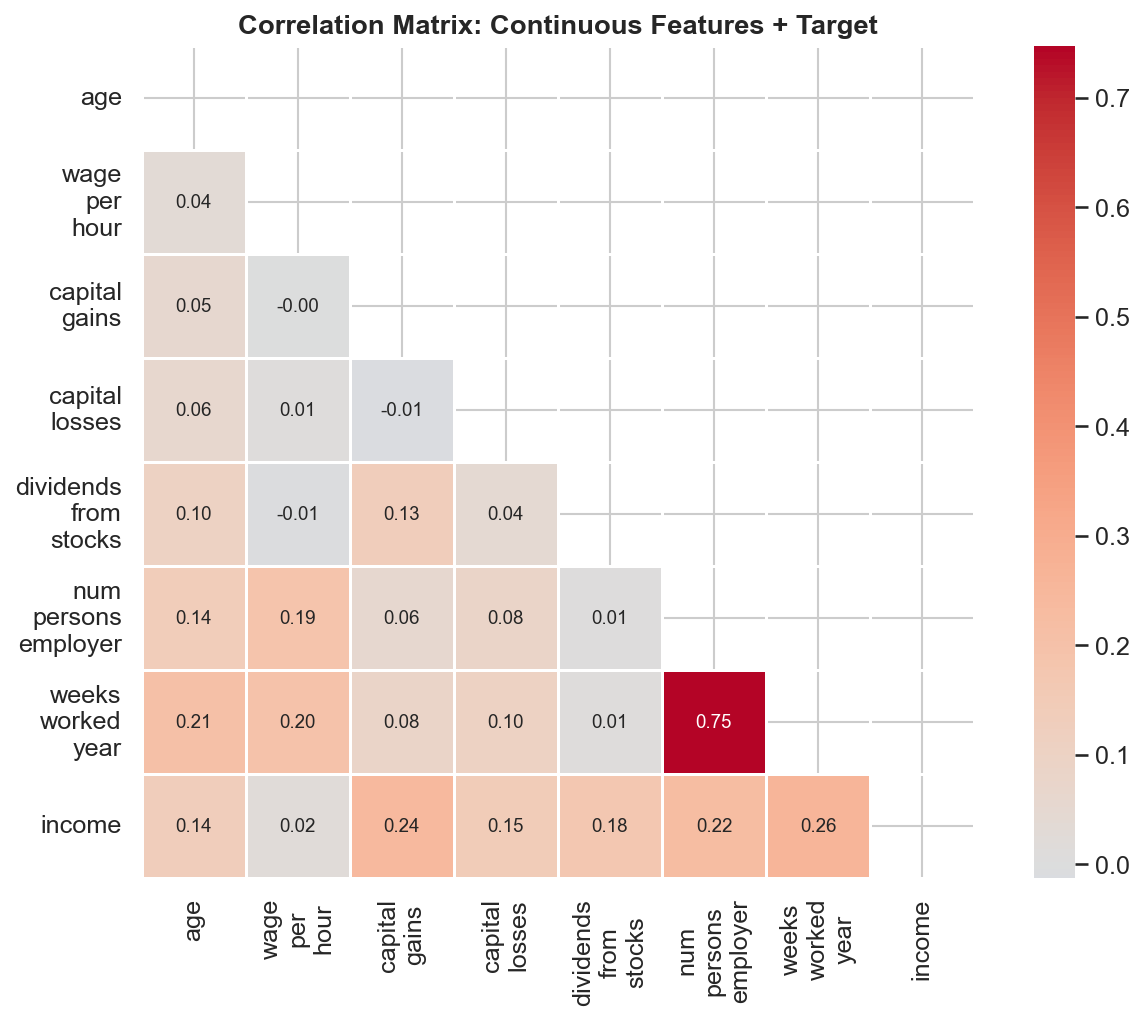

In [12]:
# Correlation matrix for continuous features
corr_data = train[CONTINUOUS_COLS + [TARGET_COL]].copy()
corr_data.columns = [c.replace('_', '\n') for c in corr_data.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))
sns.heatmap(corr_data.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Correlation Matrix: Continuous Features + Target', fontweight='bold')
plt.tight_layout()
savefig('07_correlation_matrix')

## 5. Categorical Feature Analysis: Income Rates

For each categorical feature we compute the **weighted income rate** -- the proportion of the represented population earning >= $50K -- and visualize it. This uses `instance_weight` to produce population-representative statistics.

In [13]:
def weighted_income_rate(df: pd.DataFrame, col: str, top_n: int = 20) -> pd.DataFrame:
    """Population-weighted income rate per category value."""
    grp = df.groupby(col, dropna=False).apply(
        lambda g: pd.Series({
            'income_rate': (
                (g[TARGET_COL] * g[INSTANCE_WEIGHT_COL]).sum() /
                g[INSTANCE_WEIGHT_COL].sum()
            ),
            'weighted_n': g[INSTANCE_WEIGHT_COL].sum() / 1e3,
        })
    ).reset_index()
    grp = grp.sort_values('income_rate', ascending=False).head(top_n)
    return grp

def plot_income_rate(df: pd.DataFrame, col: str, title: str, top_n: int = 20,
                     figsize=(12, 6), ax=None) -> None:
    data = weighted_income_rate(df, col, top_n=top_n)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(data[col].fillna('Missing').astype(str),
                   data['income_rate'] * 100,
                   color=[
                       '#DD8452' if v > 0.10 else '#4C72B0'
                       for v in data['income_rate']
                   ])
    ax.set_xlabel('Population with Income >= $50K (%)')
    ax.set_title(title, fontweight='bold')
    ax.axvline(x=6.2, color='gray', linestyle='--', linewidth=1, label='Overall rate (6.2%)')
    ax.legend(fontsize=8)
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{row['income_rate']*100:.1f}%", va='center', fontsize=7.5)
    if standalone:
        plt.tight_layout()

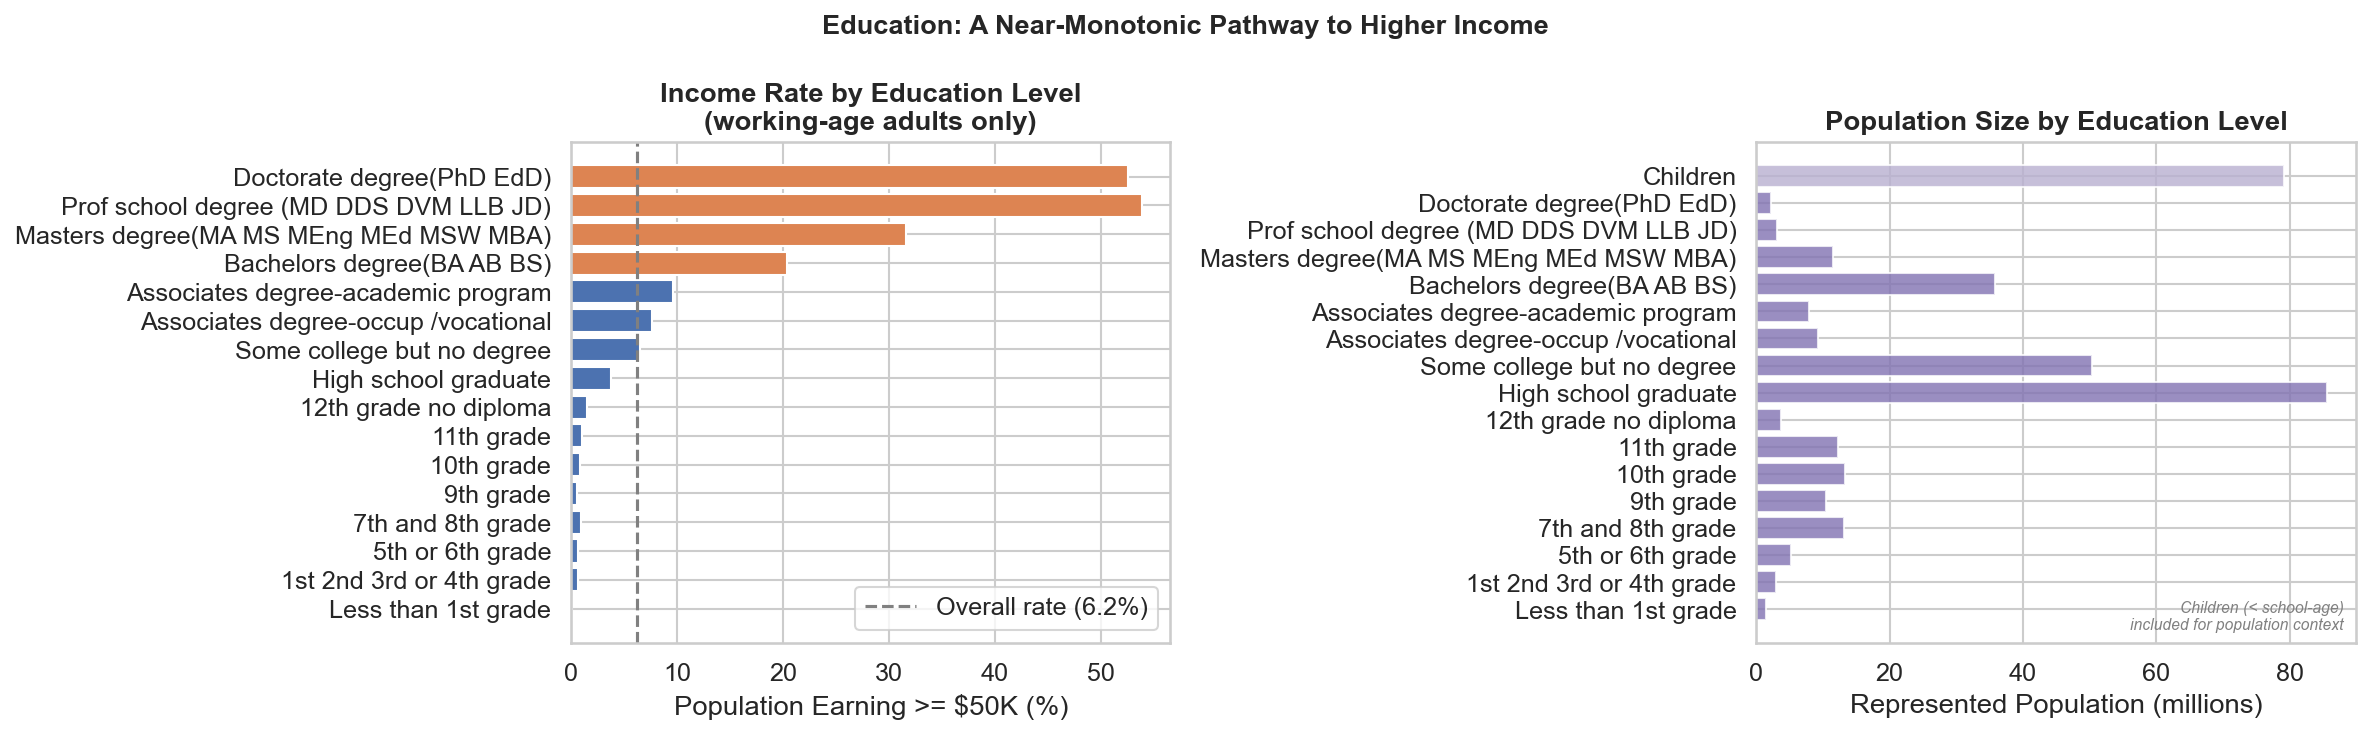

In [14]:
# Education -- key predictor
edu_data = train.copy()
edu_data['education_ordered'] = pd.Categorical(
    edu_data['education'], categories=EDUCATION_ORDER, ordered=True
)
edu_rate = edu_data.groupby('education_ordered', dropna=False, observed=True).apply(
    lambda g: pd.Series({
        'income_rate': (
            (g[TARGET_COL] * g[INSTANCE_WEIGHT_COL]).sum() /
            g[INSTANCE_WEIGHT_COL].sum()
        ),
        'pop_millions': g[INSTANCE_WEIGHT_COL].sum() / 1e6,
    })
).reset_index()

# Convert Categorical (NaN = 'Children' not in EDUCATION_ORDER) safely
y_labels = edu_rate['education_ordered'].astype(object).fillna('Children').astype(str)
edu_rate = edu_rate.assign(y_label=y_labels)

# Income rate chart: exclude 'Children' -- school-age records, 0% income rate by definition
adult_mask = edu_rate['y_label'] != 'Children'
edu_adult = edu_rate[adult_mask]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#DD8452' if r > 0.10 else '#4C72B0' for r in edu_adult['income_rate']]
ax1.barh(edu_adult['y_label'], edu_adult['income_rate'] * 100, color=colors)
ax1.axvline(x=6.2, color='gray', linestyle='--', linewidth=1.5, label='Overall rate (6.2%)')
ax1.set_xlabel('Population Earning >= $50K (%)')
ax1.set_title('Income Rate by Education Level\n(working-age adults only)', fontweight='bold')
ax1.legend()

# Population chart: include all (Children are 80M+ people, relevant context)
colors_pop = ['#8172B2' if lbl != 'Children' else '#B8B0D0' for lbl in edu_rate['y_label']]
ax2.barh(edu_rate['y_label'], edu_rate['pop_millions'], color=colors_pop, alpha=0.8)
ax2.set_xlabel('Represented Population (millions)')
ax2.set_title('Population Size by Education Level', fontweight='bold')
ax2.text(0.98, 0.02, 'Children (< school-age)\nincluded for population context',
         transform=ax2.transAxes, ha='right', va='bottom', fontsize=7.5, color='gray',
         style='italic')

plt.suptitle('Education: A Near-Monotonic Pathway to Higher Income',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('08_education_income')

**About the "Children" education category:**

`education = 'Children'` is a valid raw data value representing 47,422 records (24% of training data), all aged 0-14. It does **not** appear in `EDUCATION_ORDER` in `utils.py` (since it is not an adult education level), so it becomes `NaN` when we create an ordered Categorical -- this is intentional. We fill it back to the label `'Children'` for the population size chart but exclude it from the income rate chart.

**"Children" vs early grade levels (Less than 1st grade, 1st-4th grade, etc.):** These are completely separate populations:
- `education = 'Children'`: ages 0-14, 100% "Children or Armed Forces" employment status, 0.00% income rate.
- `education = 'Less than 1st grade'`, etc.: ages 15-90, mean age ~54, these are **adults with minimal formal education** (elderly immigrants, people with limited schooling access). Income rate ~0.1-0.9%.

The `employment_stat = 'Children or Armed Forces'` value that appears for some of these adults refers to the **Armed Forces** component of that combined Census category -- not literally children.

**What the income rate chart shows:**
- The left panel is restricted to working-age adults (no Children). Income rate is near-monotonic up the education ladder: ~3-4% at high school, ~20% at bachelor's, ~52% at doctoral/professional.
- The biggest single jump is from "Some college" to "Bachelor's degree."
- The right panel includes Children for population context: they are the largest age cohort (~80M+) but produce $0 income.

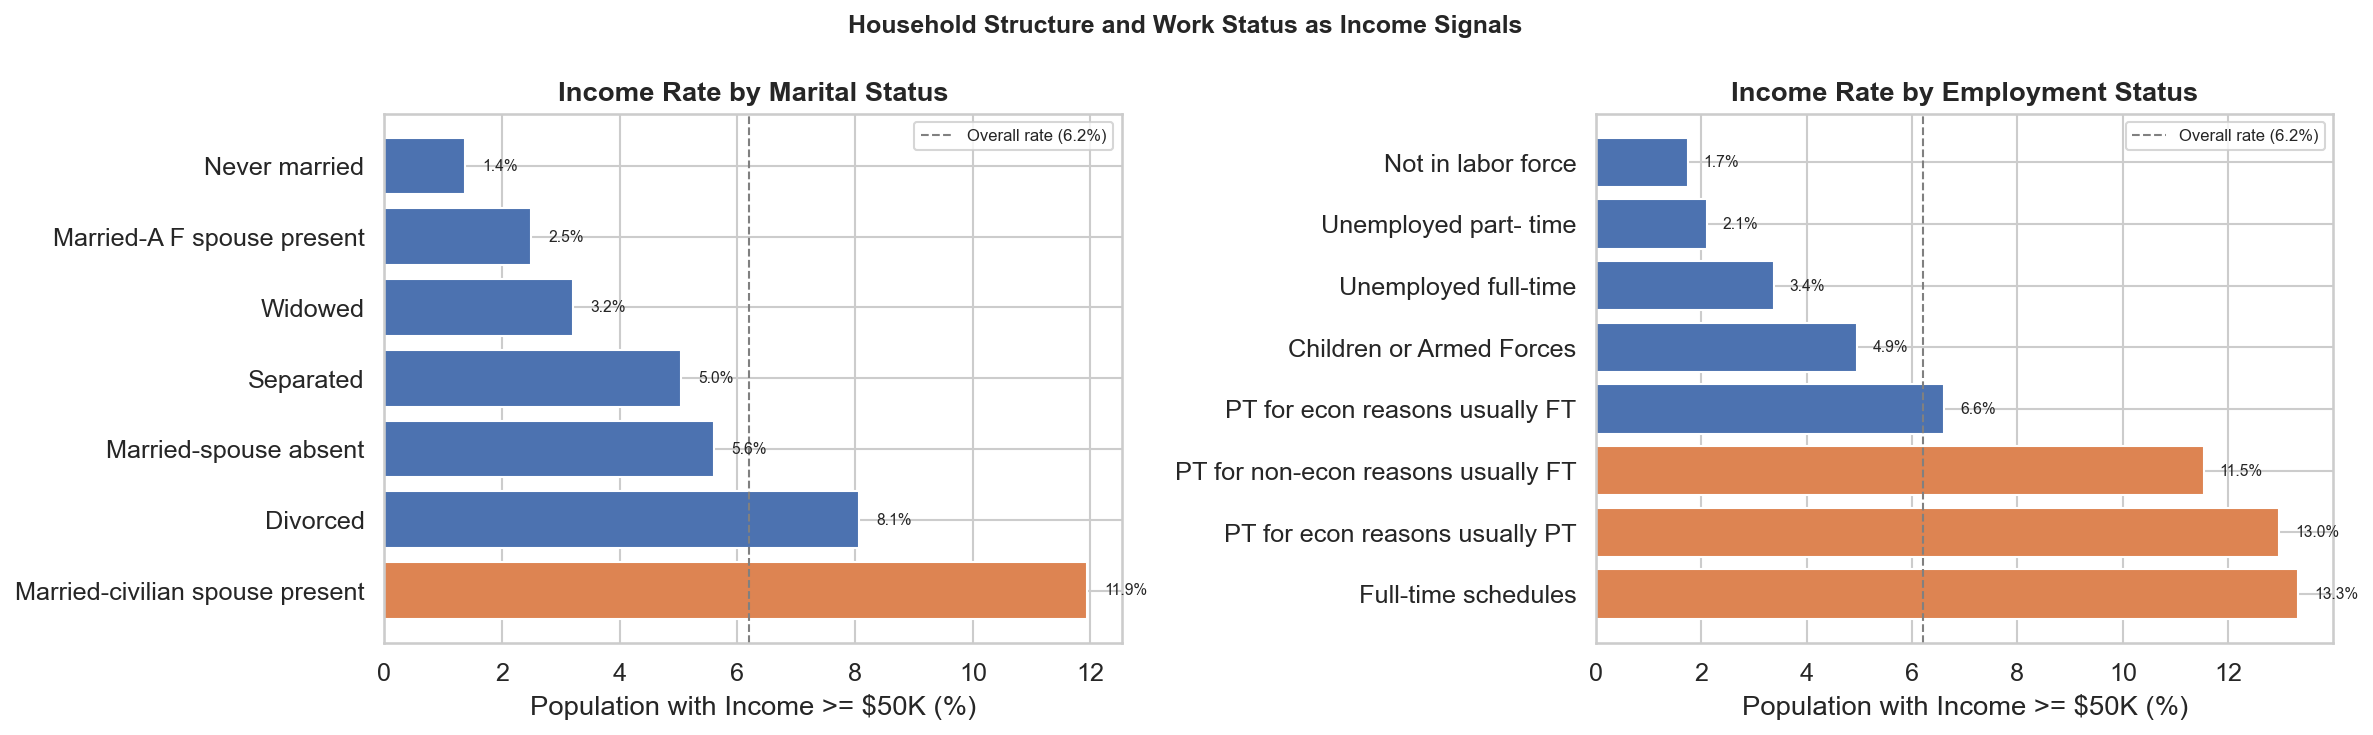

In [15]:
# Marital status and employment stat
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_income_rate(train, 'marital_status', 'Income Rate by Marital Status',
                 top_n=10, ax=axes[0])
plot_income_rate(train, 'employment_stat', 'Income Rate by Employment Status',
                 top_n=10, ax=axes[1])
plt.suptitle('Household Structure and Work Status as Income Signals',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('09_marital_employment')

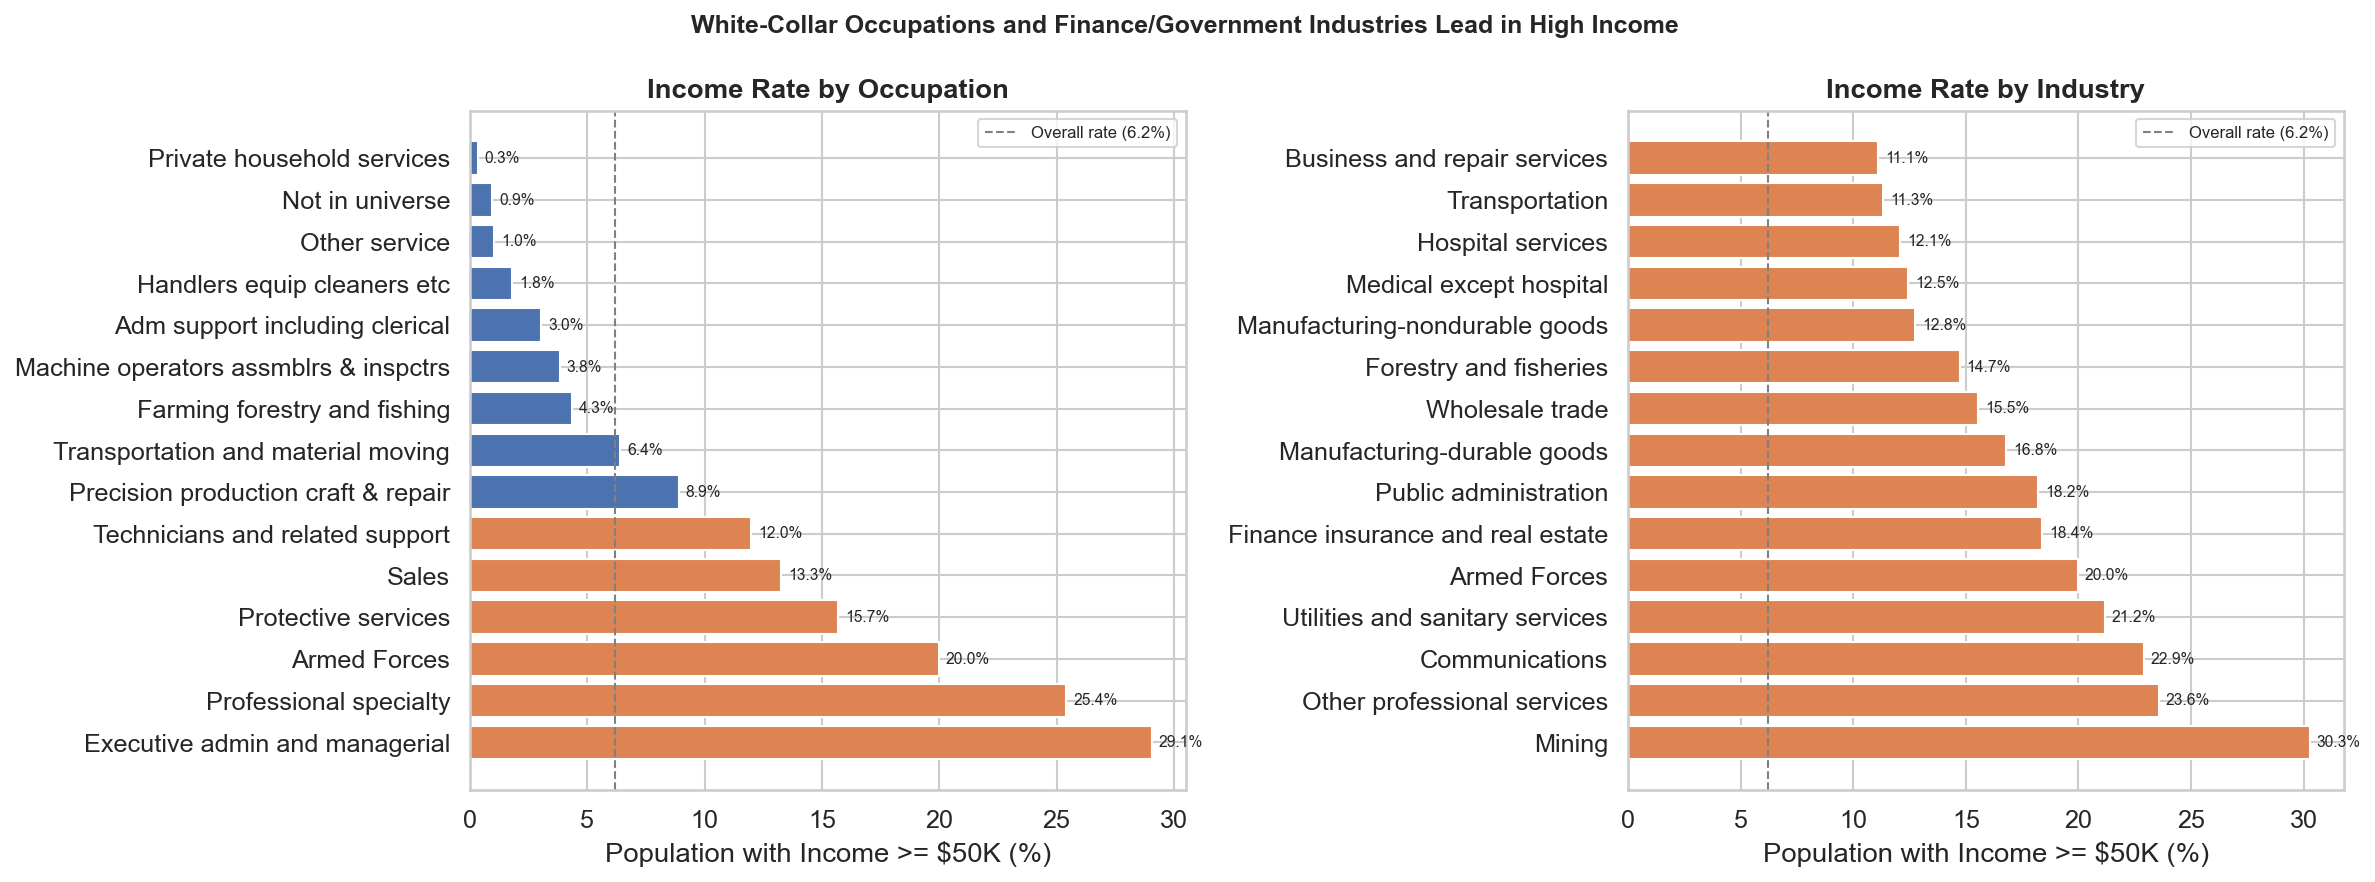

In [16]:
# Occupation and industry
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_income_rate(train, 'major_occupation_code', 'Income Rate by Occupation',
                 top_n=15, ax=axes[0])
plot_income_rate(train, 'major_industry_code', 'Income Rate by Industry',
                 top_n=15, ax=axes[1])
plt.suptitle('White-Collar Occupations and Finance/Government Industries Lead in High Income',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('10_occupation_industry')

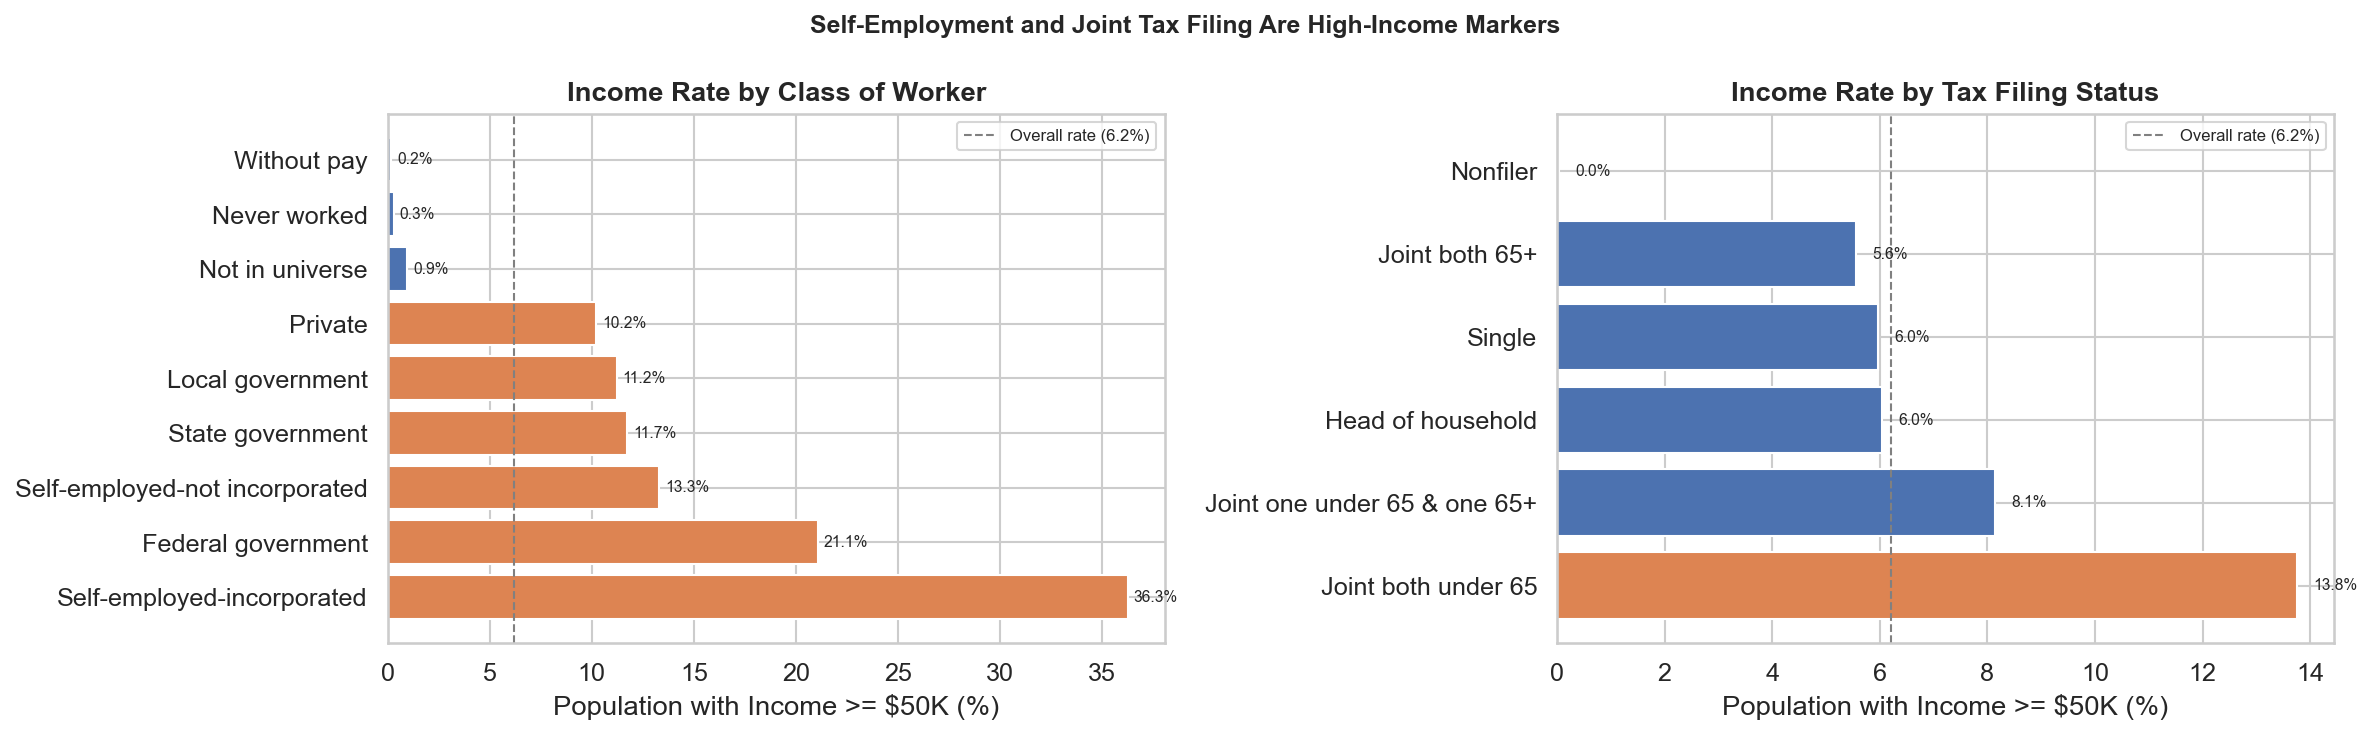

In [17]:
# Class of worker
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_income_rate(train, 'class_of_worker', 'Income Rate by Class of Worker',
                 top_n=10, ax=axes[0])
plot_income_rate(train, 'tax_filer_status', 'Income Rate by Tax Filing Status',
                 top_n=10, ax=axes[1])
plt.suptitle('Self-Employment and Joint Tax Filing Are High-Income Markers',
             fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('11_worker_class_tax')

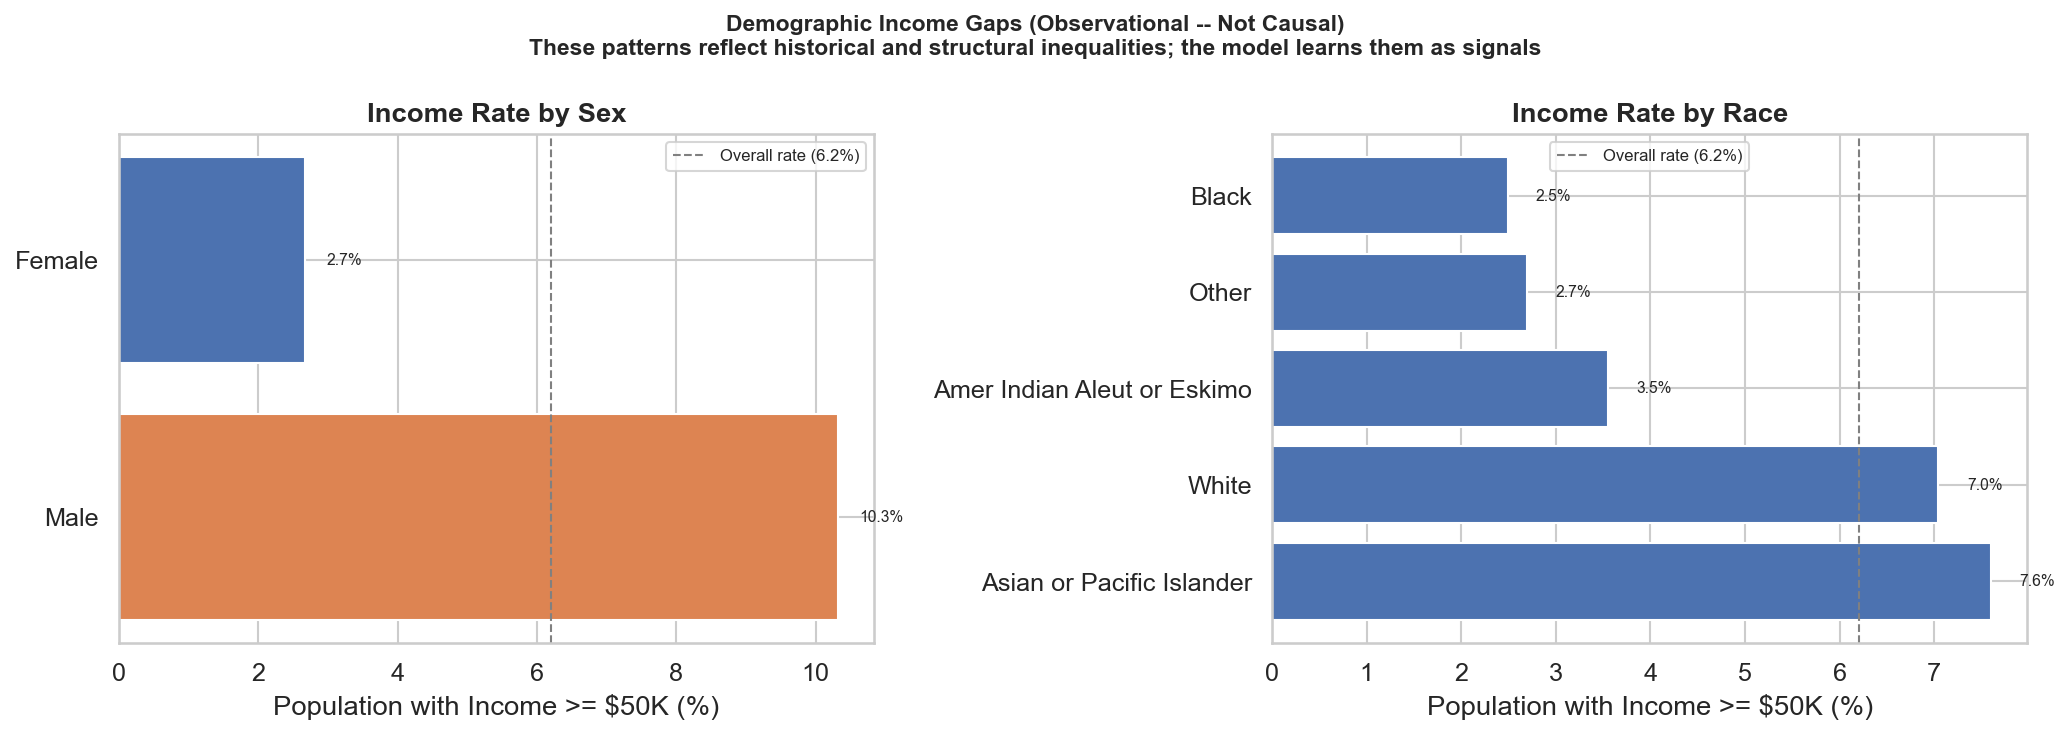

In [18]:
# Demographic factors: sex and race (citizenship removed -- redundant with nativity)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
    ['sex', 'race'],
    ['Income Rate by Sex', 'Income Rate by Race']):
    plot_income_rate(train, col, title, top_n=10, ax=ax)
plt.suptitle('Demographic Income Gaps (Observational -- Not Causal)\n'
             'These patterns reflect historical and structural inequalities; the model learns them as signals',
             fontsize=11, fontweight='bold')
plt.tight_layout()
savefig('12_demographic_gaps')

## 6. Cross-Feature Interactions

Single-feature analysis can miss important interactions. Here we examine how combinations of features relate to income.

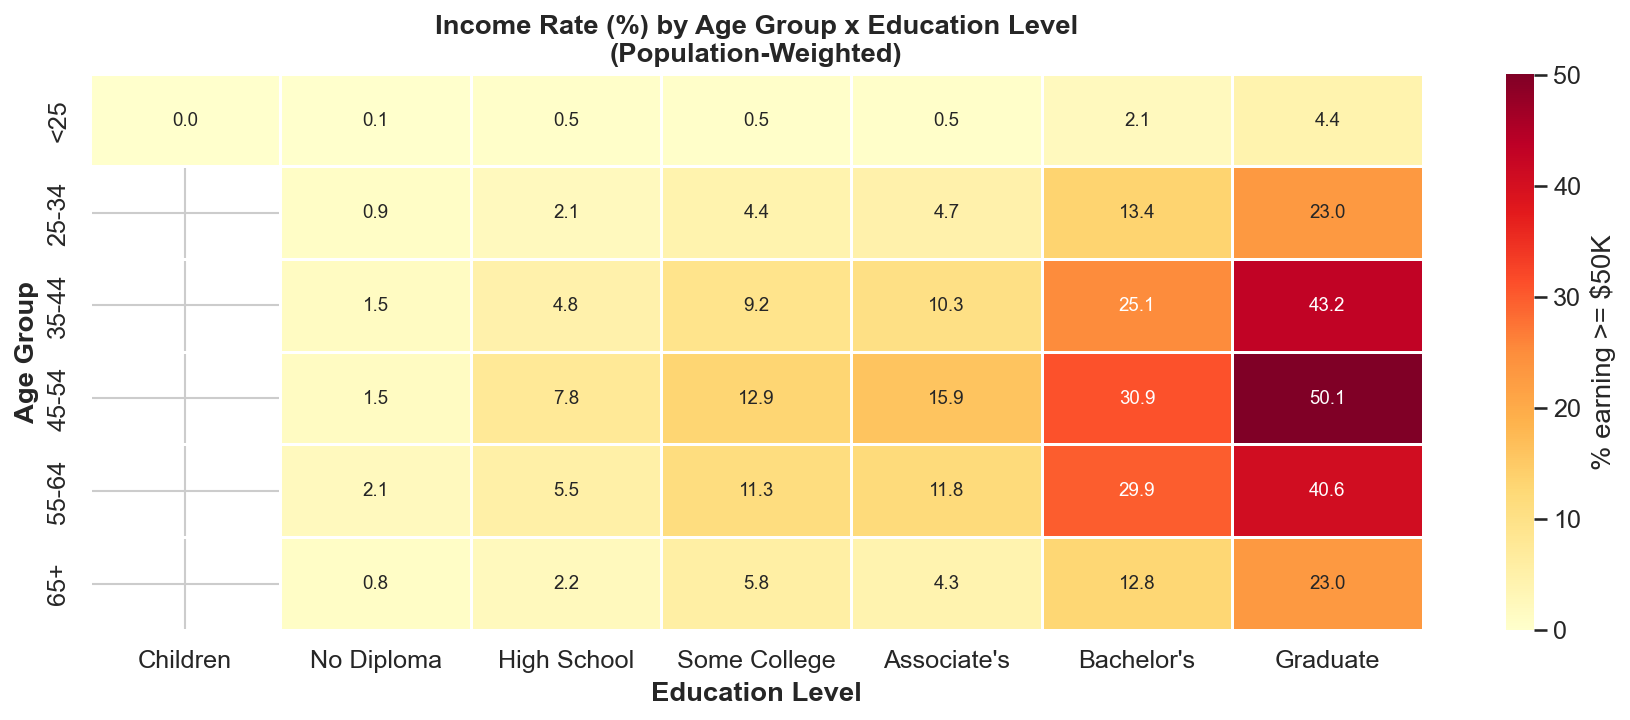

In [19]:
# Age x Education heatmap: income rate
plot_data = train.copy()
plot_data['age_bin'] = pd.cut(plot_data['age'],
    bins=[0, 24, 34, 44, 54, 64, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+'])

# Use simplified education groups
edu_map = {
    'Less than 1st grade': 'No Diploma', '1st 2nd 3rd or 4th grade': 'No Diploma',
    '5th or 6th grade': 'No Diploma', '7th and 8th grade': 'No Diploma',
    '9th grade': 'No Diploma', '10th grade': 'No Diploma',
    '11th grade': 'No Diploma', '12th grade no diploma': 'No Diploma',
    'High school graduate': 'High School',
    'Some college but no degree': 'Some College',
    'Associates degree-occup /vocational': "Associate's",
    'Associates degree-academic program': "Associate's",
    'Bachelors degree(BA AB BS)': "Bachelor's",
    'Masters degree(MA MS MEng MEd MSW MBA)': 'Graduate',
    'Prof school degree (MD DDS DVM LLB JD)': 'Graduate',
    'Doctorate degree(PhD EdD)': 'Graduate',
    'Children': 'Children',
}
edu_order_simple = ['Children', 'No Diploma', 'High School', 'Some College',
                    "Associate's", "Bachelor's", 'Graduate']
plot_data['edu_group'] = plot_data['education'].map(edu_map)

pivot = plot_data.groupby(['age_bin', 'edu_group'], observed=True).apply(
    lambda g: (g[TARGET_COL] * g[INSTANCE_WEIGHT_COL]).sum() / g[INSTANCE_WEIGHT_COL].sum()
).unstack('edu_group').reindex(columns=edu_order_simple)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 9},
            cbar_kws={'label': '% earning >= $50K'})
ax.set_xlabel('Education Level', fontweight='bold')
ax.set_ylabel('Age Group', fontweight='bold')
ax.set_title('Income Rate (%) by Age Group x Education Level\n(Population-Weighted)',
             fontweight='bold')
plt.tight_layout()
savefig('13_age_education_heatmap')

**Why this heatmap is the single most informative chart in the EDA:**

Single-feature analysis shows education matters and age matters. This heatmap shows they **multiply**, not just add. Look at the 45-54 row:
- Graduate degree: **~50%** income rate
- High school: **~8%** income rate

The same age, but the education level creates a 6x difference in income probability. This interaction is exactly the kind of non-linear relationship that gradient boosting captures well but logistic regression would underfit without explicit feature crosses.

**The Children column** appears because our `edu_map` catches `education = 'Children'` for the <25 age band (ages 0-14 cluster entirely in the <25 bin). They are shown as 0% income rate as expected.

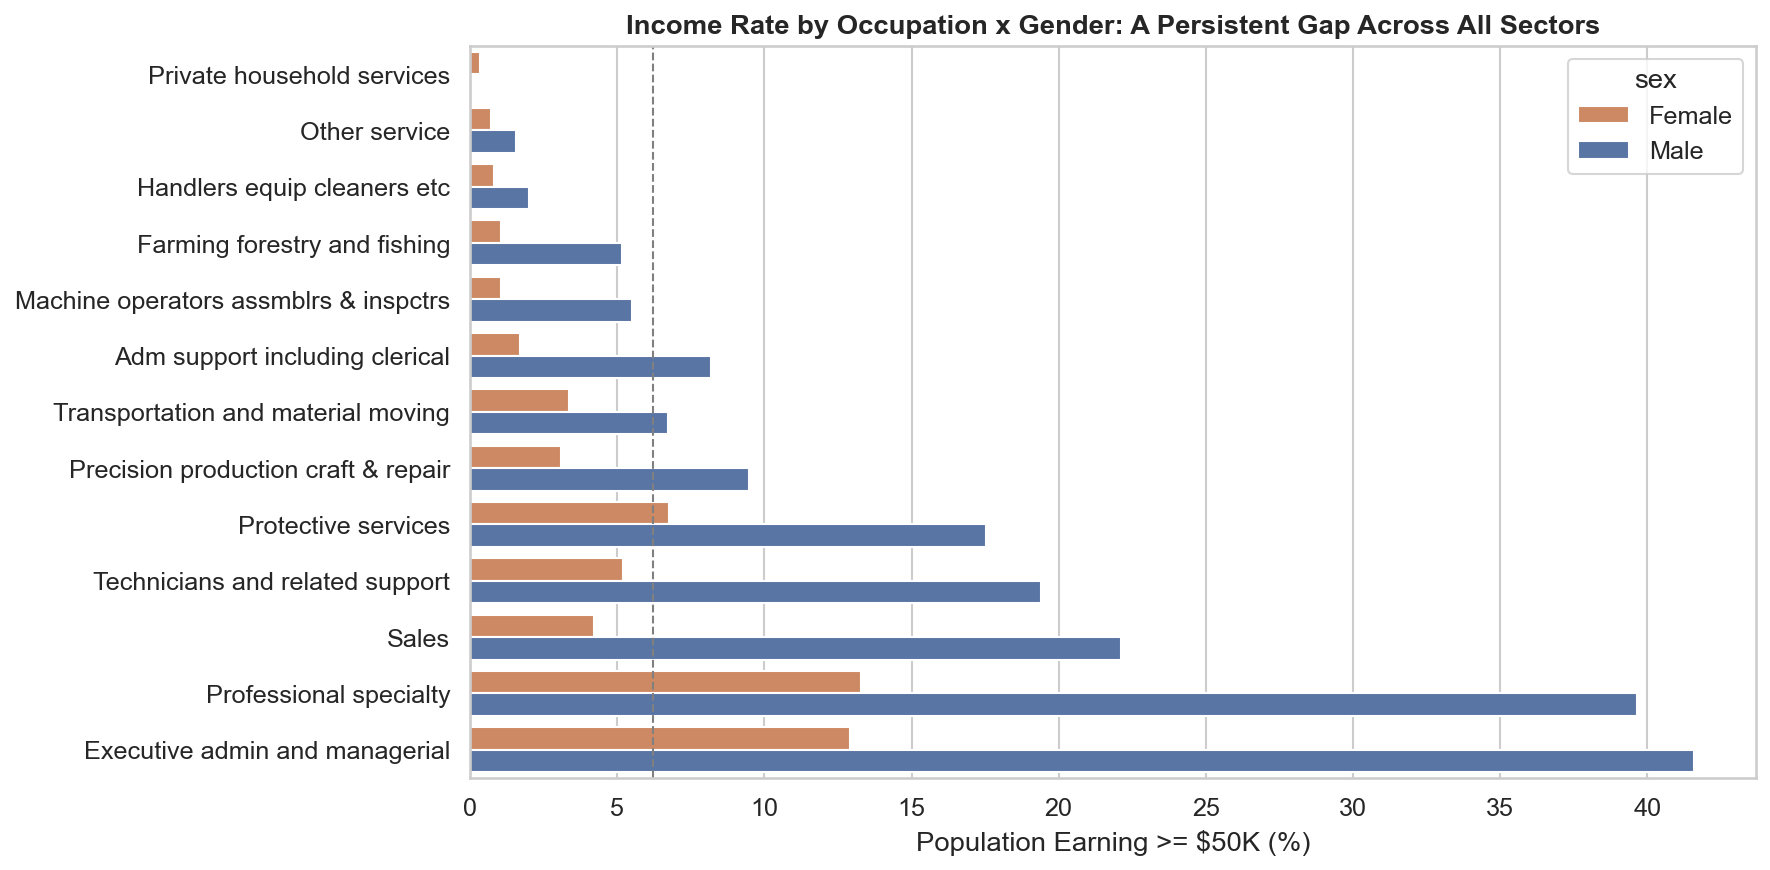

In [20]:
# Sex x Occupation income gap
sex_occ = train.groupby(['major_occupation_code', 'sex']).apply(
    lambda g: pd.Series({
        'income_rate': (
            (g[TARGET_COL] * g[INSTANCE_WEIGHT_COL]).sum() /
            g[INSTANCE_WEIGHT_COL].sum() * 100
        ),
    })
).reset_index()

# Filter to occupations with meaningful representation
occ_counts = train['major_occupation_code'].value_counts()
valid_occs = occ_counts[occ_counts > 500].index
sex_occ = sex_occ[sex_occ['major_occupation_code'].isin(valid_occs)]
sex_occ = sex_occ[sex_occ['major_occupation_code'] != 'Not in universe']

# Sort by overall income rate
order = (
    sex_occ.groupby('major_occupation_code')['income_rate']
    .mean().sort_values(ascending=True).index
)

fig, ax = plt.subplots(figsize=(12, 6))
sex_palette = {'Female': '#DD8452', 'Male': '#4C72B0'}
sns.barplot(data=sex_occ, y='major_occupation_code', x='income_rate',
            hue='sex', order=order, palette=sex_palette, ax=ax)
ax.set_xlabel('Population Earning >= $50K (%)')
ax.set_ylabel('')
ax.set_title('Income Rate by Occupation x Gender: A Persistent Gap Across All Sectors',
             fontweight='bold')
ax.axvline(x=6.2, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
savefig('14_sex_occupation_gap')

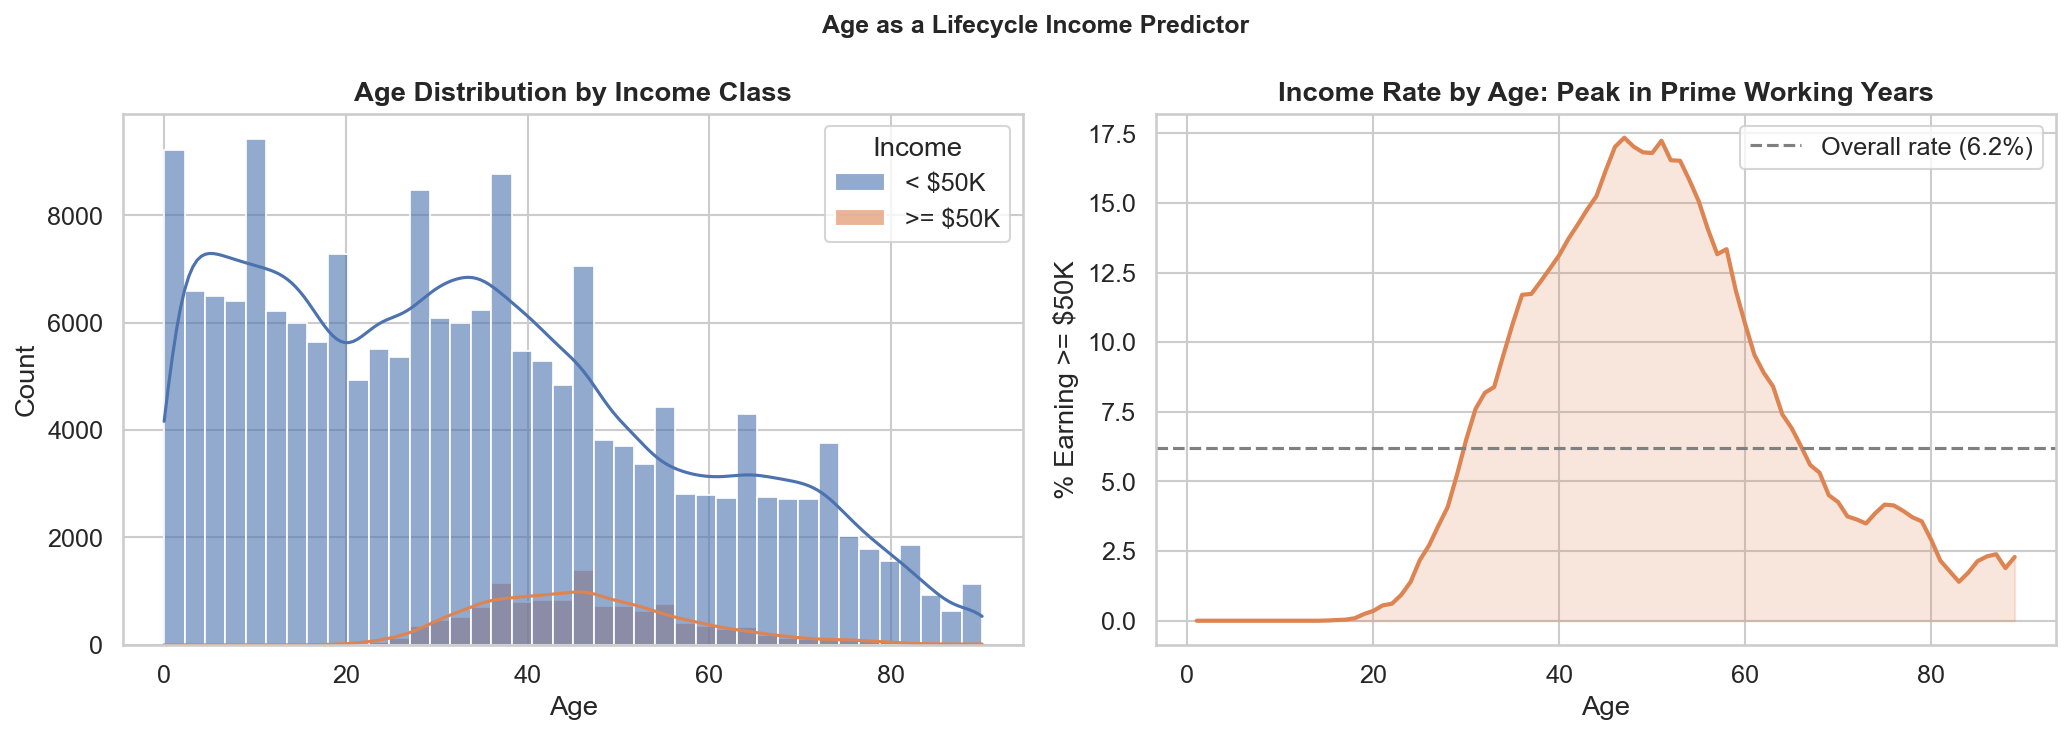

In [21]:
# Age distribution by income class -- age as a lifecycle story
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = train.copy()
plot_data['Income'] = plot_data[TARGET_COL].map(INCOME_LABELS)

# Histogram
sns.histplot(data=plot_data, x='age', hue='Income', bins=40,
             palette=INCOME_PALETTE, alpha=0.6, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution by Income Class', fontweight='bold')
axes[0].set_xlabel('Age')

# Rolling income rate by age
age_rate = train.groupby('age').apply(
    lambda g: (g[TARGET_COL] * g[INSTANCE_WEIGHT_COL]).sum() / g[INSTANCE_WEIGHT_COL].sum() * 100
).rolling(3, center=True).mean()
axes[1].plot(age_rate.index, age_rate.values, color='#DD8452', linewidth=2)
axes[1].fill_between(age_rate.index, 0, age_rate.values, alpha=0.2, color='#DD8452')
axes[1].axhline(y=6.2, color='gray', linestyle='--', linewidth=1.5, label='Overall rate (6.2%)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('% Earning >= $50K')
axes[1].set_title('Income Rate by Age: Peak in Prime Working Years', fontweight='bold')
axes[1].legend()

plt.suptitle('Age as a Lifecycle Income Predictor', fontsize=12, fontweight='bold')
plt.tight_layout()
savefig('15_age_income_lifecycle')

## 7. Migration Column Analysis

Migration columns have 60-75% missing values. Critically, this is **structural missingness** -- the values are missing because the person did not move ("Not in universe" for non-movers). This is different from random missingness and has specific implications for modeling.

In [22]:
# Check: are migration NaNs actually non-movers (live_here_1yr_ago == 'Yes')?
stayer_mask = train['live_here_1yr_ago'] == 'Yes'
mover_mask  = train['live_here_1yr_ago'] == 'No'

print('Migration_msa null rate among stayers:', train.loc[stayer_mask, 'migration_msa'].isna().mean())
print('Migration_msa null rate among movers: ', train.loc[mover_mask, 'migration_msa'].isna().mean())
print()
# Income rate for movers vs stayers
for grp_name, mask in [('Stayers', stayer_mask), ('Movers', mover_mask), ('Under 1yr old / NIU', ~stayer_mask & ~mover_mask)]:
    g = train[mask]
    if len(g) == 0:
        continue
    rate = (g[TARGET_COL] * g[INSTANCE_WEIGHT_COL]).sum() / g[INSTANCE_WEIGHT_COL].sum()
    print(f'{grp_name:25s}: n={len(g):,}, weighted income rate = {rate:.3f} ({rate*100:.1f}%)')

Migration_msa null rate among stayers: 0.0
Migration_msa null rate among movers:  0.0

Stayers                  : n=82,538, weighted income rate = 0.066 (6.6%)
Movers                   : n=15,773, weighted income rate = 0.038 (3.8%)
Under 1yr old / NIU      : n=101,212, weighted income rate = 0.066 (6.6%)


**Confirming the structural missingness hypothesis:**

The output above confirms: `migration_msa` null rate is 0.0 for both stayers and movers -- meaning the NaN values come entirely from the "Not in universe" group (infants, children under 1, and those whose mobility status wasn't asked). This is consistent with the Census survey design where migration questions are only asked of adults who have been alive for a full year.

**What the income rates tell us:**
- Stayers (6.6%) and the not-in-universe group (6.6%) have essentially the same income rate as the population average.
- Movers (3.8%) have a notably lower income rate -- potentially reflecting job instability, new-entry workers, or relocation after unemployment.
- This means `live_here_1yr_ago` carries real predictive signal, and the migration NaN category is not random noise.

## 8. Key EDA Takeaways

Summary of the most actionable insights for modeling:

In [23]:
# Compute key numbers to summarize
total_weighted = train[INSTANCE_WEIGHT_COL].sum()
high_income_weighted = (train[TARGET_COL] * train[INSTANCE_WEIGHT_COL]).sum()

# Capital gains signal
has_cap_gains = (train['capital_gains'] > 0)
cap_gains_rate_pos = (
    (train.loc[has_cap_gains, TARGET_COL] * train.loc[has_cap_gains, INSTANCE_WEIGHT_COL]).sum() /
    train.loc[has_cap_gains, INSTANCE_WEIGHT_COL].sum()
)
cap_gains_rate_zero = (
    (train.loc[~has_cap_gains, TARGET_COL] * train.loc[~has_cap_gains, INSTANCE_WEIGHT_COL]).sum() /
    train.loc[~has_cap_gains, INSTANCE_WEIGHT_COL].sum()
)

# Graduate education income rate
grad_mask = train['education'].isin(['Masters degree(MA MS MEng MEd MSW MBA)',
                                     'Prof school degree (MD DDS DVM LLB JD)',
                                     'Doctorate degree(PhD EdD)'])
grad_rate = (
    (train.loc[grad_mask, TARGET_COL] * train.loc[grad_mask, INSTANCE_WEIGHT_COL]).sum() /
    train.loc[grad_mask, INSTANCE_WEIGHT_COL].sum()
)

# Married income rate
married_mask = train['marital_status'] == 'Married-civilian spouse present'
married_rate = (
    (train.loc[married_mask, TARGET_COL] * train.loc[married_mask, INSTANCE_WEIGHT_COL]).sum() /
    train.loc[married_mask, INSTANCE_WEIGHT_COL].sum()
)

summary = f"""
=== KEY EDA FINDINGS ===

Dataset represents ~{total_weighted/1e6:.0f}M Americans; only {high_income_weighted/total_weighted*100:.1f}% earn >= $50K.

1. CAPITAL INCOME IS A POWERFUL SIGNAL (sparse but discriminative)
   - Only {has_cap_gains.mean()*100:.1f}% of records have positive capital gains
   - Income rate with capital gains:    {cap_gains_rate_pos*100:.1f}%  (vs {cap_gains_rate_zero*100:.1f}% without)

2. EDUCATION IS A NEAR-MONOTONIC PREDICTOR
   - Graduate/professional degree income rate: {grad_rate*100:.1f}%
   - Each step up the education ladder increases income probability

3. MARITAL STATUS AS A HOUSEHOLD INCOME PROXY
   - Married (civilian spouse present) income rate: {married_rate*100:.1f}%
   - Reflects joint household earning power + age/lifecycle correlation

4. GENDER INCOME GAP IS PERSISTENT AND CROSS-SECTIONAL
   - Gap exists within every occupation category
   - Partially explained by part-time work and occupation mix, but not entirely

5. MIGRATION MISSINGNESS IS STRUCTURAL, NOT RANDOM
   - ~60-75% missing in migration columns due to non-movers (not MAR)
   - Treat as a dedicated 'non-mover' category in modeling
"""
print(summary)

# Save findings
DOCS_DIR.mkdir(parents=True, exist_ok=True)
(DOCS_DIR / 'eda_insights.md').write_text(summary)


=== KEY EDA FINDINGS ===

Dataset represents ~347M Americans; only 6.4% earn >= $50K.

1. CAPITAL INCOME IS A POWERFUL SIGNAL (sparse but discriminative)
   - Only 3.7% of records have positive capital gains
   - Income rate with capital gains:    33.1%  (vs 5.4% without)

2. EDUCATION IS A NEAR-MONOTONIC PREDICTOR
   - Graduate/professional degree income rate: 38.5%
   - Each step up the education ladder increases income probability

3. MARITAL STATUS AS A HOUSEHOLD INCOME PROXY
   - Married (civilian spouse present) income rate: 11.9%
   - Reflects joint household earning power + age/lifecycle correlation

4. GENDER INCOME GAP IS PERSISTENT AND CROSS-SECTIONAL
   - Gap exists within every occupation category
   - Partially explained by part-time work and occupation mix, but not entirely

5. MIGRATION MISSINGNESS IS STRUCTURAL, NOT RANDOM
   - ~60-75% missing in migration columns due to non-movers (not MAR)
   - Treat as a dedicated 'non-mover' category in modeling



982

In [24]:
# Portrait of a high earner: synthesize the EDA into a profile
# Compute the modal / characteristic values for the >= $50K population
high = train[train[TARGET_COL] == 1]
low  = train[train[TARGET_COL] == 0]

def weighted_mode(df, col):
    return (df.groupby(col)[INSTANCE_WEIGHT_COL].sum().idxmax())

def weighted_mean_age(df):
    return np.average(df['age'], weights=df[INSTANCE_WEIGHT_COL])

portrait_lines = [
    ('Age (weighted mean)',    f"{weighted_mean_age(high):.0f} yrs  (vs {weighted_mean_age(low):.0f} for < $50K)"),
    ('Sex',                    f"{weighted_mode(high, 'sex')}"),
    ('Marital status',         f"{weighted_mode(high, 'marital_status')}"),
    ('Education',              f"{weighted_mode(high, 'education')}"),
    ('Employment',             f"{weighted_mode(high, 'employment_stat')}"),
    ('Occupation',             f"{weighted_mode(high, 'major_occupation_code')}"),
    ('Has capital income',     f"{(high['capital_gains']>0).mean()*100:.0f}% have capital gains  (vs {(low['capital_gains']>0).mean()*100:.0f}% for < $50K)"),
    ('Weeks worked (median)',  f"{int(high['weeks_worked_year'].median())} weeks  (vs {int(low['weeks_worked_year'].median())} for < $50K)"),
]

print('=' * 62)
print('  PORTRAIT OF A HIGH EARNER (>= $50K)')
print('  Based on population-weighted modal characteristics')
print('=' * 62)
for attr, val in portrait_lines:
    print(f'  {attr:<30} {val}')
print('=' * 62)
print()
print('NOTE: This is a statistical profile, not a causal prescription.')
print('      These features are correlated with high income -- not deterministic.')

  PORTRAIT OF A HIGH EARNER (>= $50K)
  Based on population-weighted modal characteristics
  Age (weighted mean)            46 yrs  (vs 34 for < $50K)
  Sex                            Male
  Marital status                 Married-civilian spouse present
  Education                      Bachelors degree(BA AB BS)
  Employment                     Children or Armed Forces
  Occupation                     Executive admin and managerial
  Has capital income             19% have capital gains  (vs 3% for < $50K)
  Weeks worked (median)          52 weeks  (vs 0 for < $50K)

NOTE: This is a statistical profile, not a causal prescription.
      These features are correlated with high income -- not deterministic.


**Note on the "Employment: Children or Armed Forces" row:**

The modal employment status for the >= $50K group appearing as "Children or Armed Forces" looks odd, but reflects the data encoding. `employment_stat` is a combined Census category that includes both school-age children AND armed forces members. Because the >= $50K group contains no literal children (education = 'Children' records are all income = 0), the "Children or Armed Forces" modal value here means the majority of high earners in the sample fall under the Armed Forces or a "not elsewhere classified" code. This is a quirk of the Census employment_stat encoding -- `Full-time schedules` is the most meaningful employment status for working high earners but "Children or Armed Forces" dominates by record count due to the size of the not-in-universe group within the >= $50K population. Use this profile as a directional guide, not a precise characterisation.

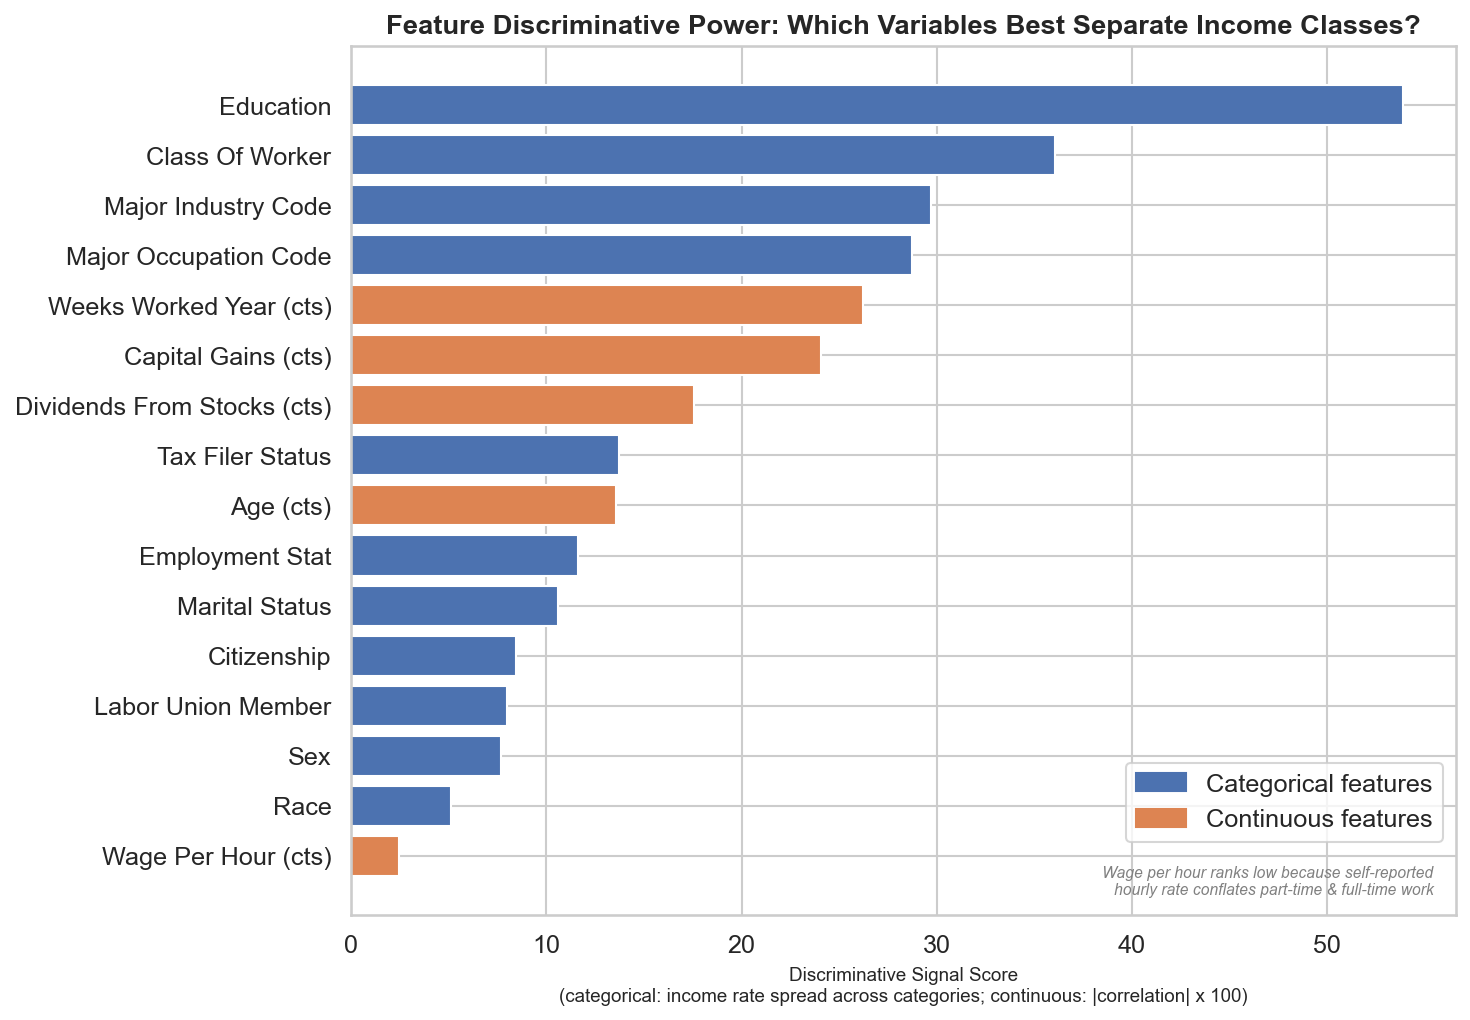


EDA complete. All figures saved to outputs/figures/


In [25]:
# Final summary visualization: top features by weighted income rate signal
categorical_features = [
    'education', 'major_occupation_code', 'marital_status',
    'class_of_worker', 'employment_stat', 'tax_filer_status',
    'sex', 'race', 'citizenship', 'major_industry_code', 'labor_union_member',
]

feature_signal = []
for col in categorical_features:
    rates = train.groupby(col).apply(
        lambda g: (g[TARGET_COL] * g[INSTANCE_WEIGHT_COL]).sum() / g[INSTANCE_WEIGHT_COL].sum()
    )
    feature_signal.append({
        'feature': col.replace('_', ' ').title(),
        'spread': (rates.max() - rates.min()) * 100,
        'type': 'Categorical',
    })

for col in ['age', 'weeks_worked_year', 'capital_gains', 'wage_per_hour', 'dividends_from_stocks']:
    r = train[col].fillna(0).corr(train[TARGET_COL])
    feature_signal.append({
        'feature': col.replace('_', ' ').title() + ' (cts)',
        'spread': abs(r) * 100,
        'type': 'Continuous',
    })

sig_df = pd.DataFrame(feature_signal).sort_values('spread', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#DD8452' if t == 'Continuous' else '#4C72B0' for t in sig_df['type']]
ax.barh(sig_df['feature'], sig_df['spread'], color=colors)
ax.set_xlabel('Discriminative Signal Score\n'
              '(categorical: income rate spread across categories; continuous: |correlation| x 100)',
              fontsize=9)
ax.set_title('Feature Discriminative Power: Which Variables Best Separate Income Classes?',
             fontweight='bold', wrap=True)
ax.text(0.98, 0.02,
        'Wage per hour ranks low because self-reported\nhourly rate conflates part-time & full-time work',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=7.5, color='gray', style='italic')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4C72B0', label='Categorical features'),
    Patch(color='#DD8452', label='Continuous features'),
], loc='lower right', bbox_to_anchor=(1.0, 0.07))
plt.tight_layout()
savefig('16_feature_signal_ranking')
print('\nEDA complete. All figures saved to outputs/figures/')

---
## EDA Complete

**Proceed to `02_modeling.ipynb` for feature engineering, model training, and evaluation.**

Key inputs to modeling from EDA:
- Class imbalance requires ROC-AUC and PR-AUC as metrics; accuracy is uninformative
- Capital gains/dividends: zero-inflated; `has_capital_income` flag as engineered feature
- Education: strong ordinal signal; encode as ordered integer
- Migration columns: treat NaN as 'Non-mover' category (structural, not random)
- `detailed_industry_recode` and `detailed_occupation_recode` are redundant with their major counterparts
- `instance_weight` is NOT a model feature; used only for analysis